# 3. Dimensionality reduction and Clustering

This notebook documents the EDA, Dimensionality reduction and Clustering of the [OSMI Mental Health in Tech Survey 2016](https://www.kaggle.com/datasets/osmi/mental-health-in-tech-2016), according to _Task 1: Mental Health in Technology-related Jobs_ of the Unsupervised Learning and Feature Engineering course (DLBDSMLUSL01).

The written report is not part of the repository.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)

from dotenv import load_dotenv
from pathlib import Path
BASE_PATH = str(Path().cwd().parent.resolve() / "utils")
import os
import sys
sys.path.append(BASE_PATH)

from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score, adjusted_rand_score
from sklearn.preprocessing import OrdinalEncoder

from skbio.stats.distance import DistanceMatrix, mantel

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from scipy.spatial.distance import squareform, is_valid_dm

from statsmodels.stats.multitest import multipletests

from itertools import combinations

# This function is in this repository
from metrics import gower_matrix

In [2]:
load_dotenv(Path().cwd().parent.joinpath(".env"))

True

In [3]:
# Dataset location
LOCATION_DATSET = Path(os.getenv("LOCATION_DATASET")).parent

In [4]:
df = pd.read_csv(LOCATION_DATSET.joinpath("osmi_mental_health_clean.csv"), index_col=0)

In [5]:
#Verify no NaN values are in the dataset
df.isna().sum().sum()

np.int64(0)

In [6]:
DATA_UTILS = Path(os.getenv("DATA_UTILS"))

## EDA

In [7]:
n_samples, n_columns = df.shape

- 81% of surveyed worked wor for a company
- 19% are self-employed
- Age range is between 17 and 55 years old, with a mean of 33.6 years old.
- Around 40% of surveyed worker currently have a mental health disorder.
- 50% of workers have been diagnosed before with a mental health disorder by a medical professional
- Almost 60% have seeked help -> High awareness in the population is likely
- Tech industry still has a majority of male workers
- Around 65% of female workers have been diagnosed with a mental health disorder in the past in contrast to 44% amongst the male workers.  
  Among non-binary workers, 77% of them have been diagnosed in past.
- Female and non-binary workers have seeked help of a health professional before with 75% and 88% respectively, in contrast only 52% of men have done so

In [8]:
df["What is your age?"].describe()

count    1413.000000
mean       33.630573
std         7.289208
min        17.000000
25%        28.000000
50%        33.000000
75%        38.000000
max        55.000000
Name: What is your age?, dtype: float64

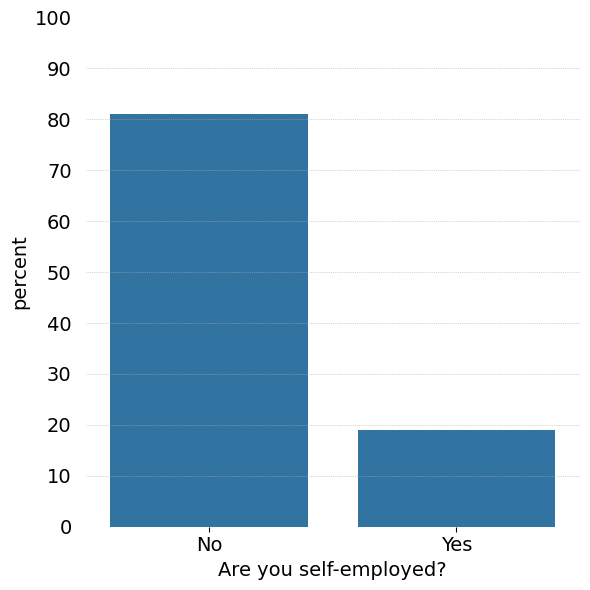

In [9]:
# How many people are self-employed
fig, ax = plt.subplots(figsize=(6,6), nrows=1, ncols=1)
sns.countplot(data=df, x="Are you self-employed?", stat="percent", ax=ax)
ax.set_xticks([0,1])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylim([0,100])
ax.set_xticklabels(["No", "Yes"], fontsize=14)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
fig.tight_layout()

In [10]:
df[["What is your gender?", "What is your age?"]].groupby("What is your gender?").describe()

What is your age?                                         \
                                 count       mean       std   min   25%   50%   
What is your gender?                                                            
female                           336.0  33.720238  8.059425  19.0  27.0  32.0   
male                            1042.0  33.730326  7.037106  17.0  29.0  33.0   
non-binary                        35.0  29.800000  5.905132  20.0  26.0  30.0   

                                  
                       75%   max  
What is your gender?              
female                38.0  55.0  
male                  38.0  55.0  
non-binary            33.0  46.0

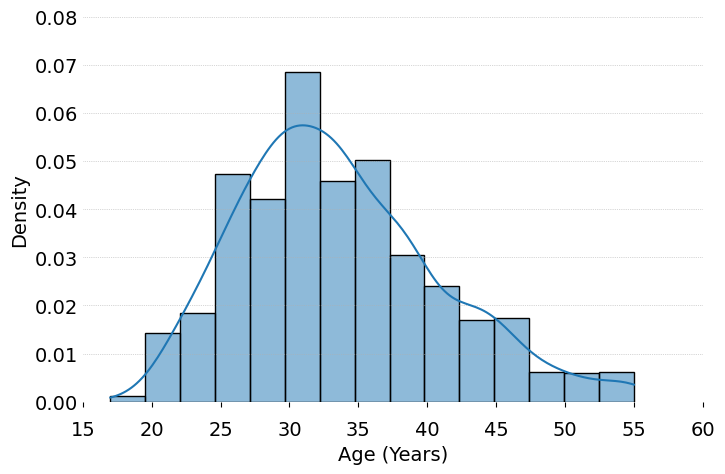

In [11]:
fig, ax = plt.subplots(figsize=(8,5), nrows=1, ncols=1)
sns.histplot(df, x ="What is your age?", bins=15, kde=True, stat="density", alpha=0.5, ax=ax)

ax.grid(True, linewidth=0.5, linestyle=':', axis="y")
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
ax.set_xlabel("Age (Years)", fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", pad=10)

In [12]:
df_explore = df.copy()

In [13]:
encoder = OrdinalEncoder(categories=[["No", "Yes", "Maybe"]])
df_explore["Do you currently have a mental health disorder?"] = encoder.fit_transform(df_explore[["Do you currently have a mental health disorder?"]]).astype(np.int64)

df_explore["Have you been diagnosed with a mental health condition by a medical professional?"] = encoder.transform(df_explore[["Have you been diagnosed with a mental health condition by a medical professional?"]].values).astype(np.int64)

/Users/jorgetellez/opt/anaconda3/envs/unsup/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


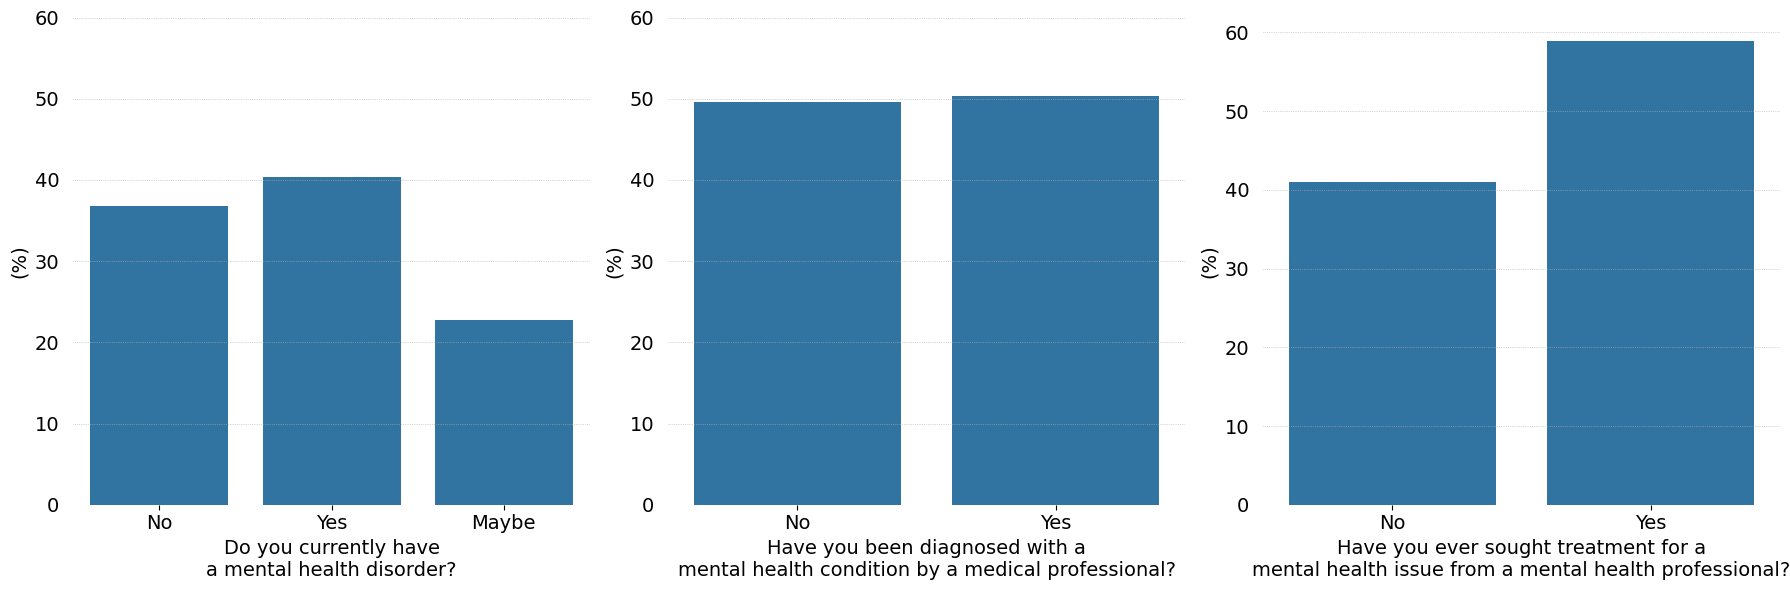

In [14]:
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=3)
sns.countplot(df_explore, x="Do you currently have a mental health disorder?", stat="percent", ax=axs[0])
axs[0].set_xticks([0,1,2])
axs[0].set_xticklabels(["No", "Yes", "Maybe"], fontsize=14)
sns.countplot(df_explore, x="Have you been diagnosed with a mental health condition by a medical professional?", stat="percent", ax=axs[1])
axs[1].set_xticks([0,1])
axs[1].set_xticklabels(["No", "Yes"], fontsize=14)
sns.countplot(df_explore, x="Have you ever sought treatment for a mental health issue from a mental health professional?", stat="percent", ax=axs[2])
axs[2].set_xticks([0,1])
axs[2].set_xticklabels(["No", "Yes"], fontsize=14)

for ax in axs:
    question = ax.get_xlabel().split()
    idx = len(question) // 2
    wrapped_question = f"{" ".join(question[:idx])}\n{" ".join(question[idx:])}"
    #ax.set_title(f"{ax.get_xlabel()}", wrap=True, fontsize=11)
    ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_yticks(np.arange(0,70,10))
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
    ax.tick_params(axis="y", length=0, pad=10)    
    ax.set_xlabel(wrapped_question, fontsize=14)
    ax.set_ylabel("(%)", fontsize=14)
fig.tight_layout()

In [15]:
gender_count = df["What is your gender?"].value_counts()
gender_count

What is your gender?
male          1042
female         336
non-binary      35
Name: count, dtype: int64

In [16]:
current_disorders_by_gender = (
    df_explore
        .loc[:, ["What is your gender?", "Do you currently have a mental health disorder?"]]
        .groupby("What is your gender?")
        .value_counts(normalize=True)
)
current_disorders_by_gender = current_disorders_by_gender.to_frame().sort_index().reset_index()
current_disorders_by_gender

,What is your gender?,Do you currently have a mental health disorder?,proportion
0,female,0,0.291667
1,female,1,0.538690
2,female,2,0.169643
3,male,0,0.403071
4,male,1,0.351248
5,male,2,0.245681
6,non-binary,0,0.057143
7,non-binary,1,0.685714
8,non-binary,2,0.257143


In [17]:
diagnosed_by_gender = (
    df_explore
        .loc[:, ["What is your gender?", "Have you been diagnosed with a mental health condition by a medical professional?"]]
        .groupby("What is your gender?")
        .value_counts(normalize=True)
)
diagnosed_by_gender = diagnosed_by_gender.to_frame().sort_index().reset_index()
diagnosed_by_gender

,What is your gender?,Have you been diagnosed with a mental health condition by a medical professional?,proportion
0,female,0,0.348214
1,female,1,0.651786
2,male,0,0.552783
3,male,1,0.447217
4,non-binary,0,0.228571
5,non-binary,1,0.771429


In [18]:
seeked_help_by_gender = (
    df_explore
        .loc[:, ["What is your gender?", "Have you ever sought treatment for a mental health issue from a mental health professional?"]]
        .groupby("What is your gender?")
        .value_counts(normalize=True)
)
seeked_help_by_gender = seeked_help_by_gender.to_frame().sort_index().reset_index()
seeked_help_by_gender

,What is your gender?,Have you ever sought treatment for a mental health issue from a mental health professional?,proportion
0,female,0,0.250000
1,female,1,0.750000
2,male,0,0.472169
3,male,1,0.527831
4,non-binary,0,0.114286
5,non-binary,1,0.885714


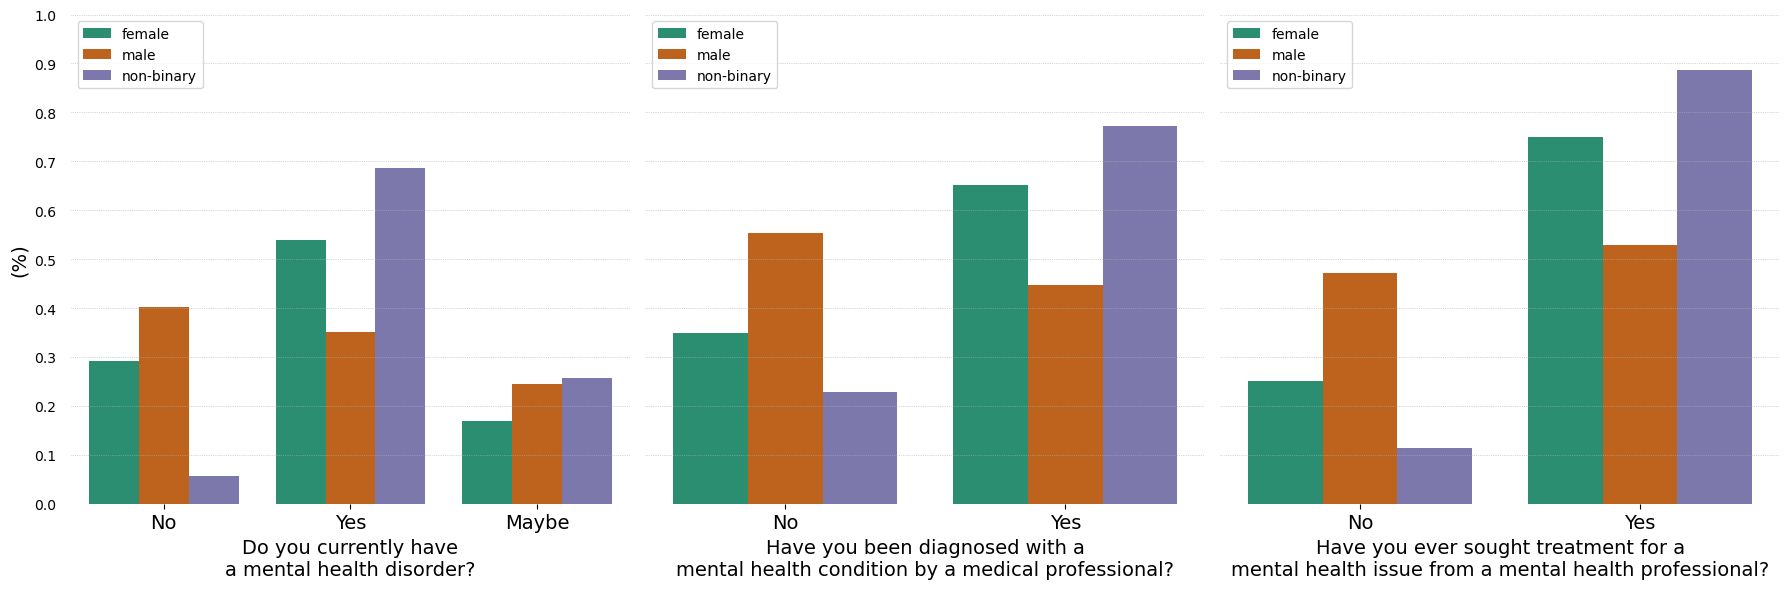

In [19]:
question_1 = "Do you currently have a mental health disorder?"
question_2 = "Have you been diagnosed with a mental health condition by a medical professional?"
question_3 = "Have you ever sought treatment for a mental health issue from a mental health professional?"

fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=3, sharey=True)

for question, feature, ax in zip((current_disorders_by_gender, diagnosed_by_gender, seeked_help_by_gender),(question_1, question_2, question_3), axs):

    sns.barplot(
        question,
        x=feature,
        y="proportion",
        hue="What is your gender?",
        palette="Dark2",
        ax=ax)

    caption = ax.get_xlabel().split()
    idx = len(caption) // 2
    wrapped_question = f"{" ".join(caption[:idx])}\n{" ".join(caption[idx:])}"
    
    ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="y", length=0, pad=10)
    ax.set_xlabel(None)
    ax.set_xlabel(wrapped_question, fontsize=14)
    ax.set_yticks(np.arange(0,1.1,.1))
    ax.set_ylabel("(%)", fontsize=14)
    ax.legend(loc="upper left")
axs[0].set_xticks([0,1,2])
axs[0].set_xticklabels(["No", "Yes", "Maybe"], fontsize=14)
axs[1].set_xticks([0,1])
axs[1].set_xticklabels(["No", "Yes"], fontsize=14)
axs[2].set_xticks([0,1])
axs[2].set_xticklabels(["No", "Yes"], fontsize=14)
fig.tight_layout()

In [20]:
roles = df["Which of the following best describes your work position?"].value_counts()
roles = (roles / roles.sum())*100

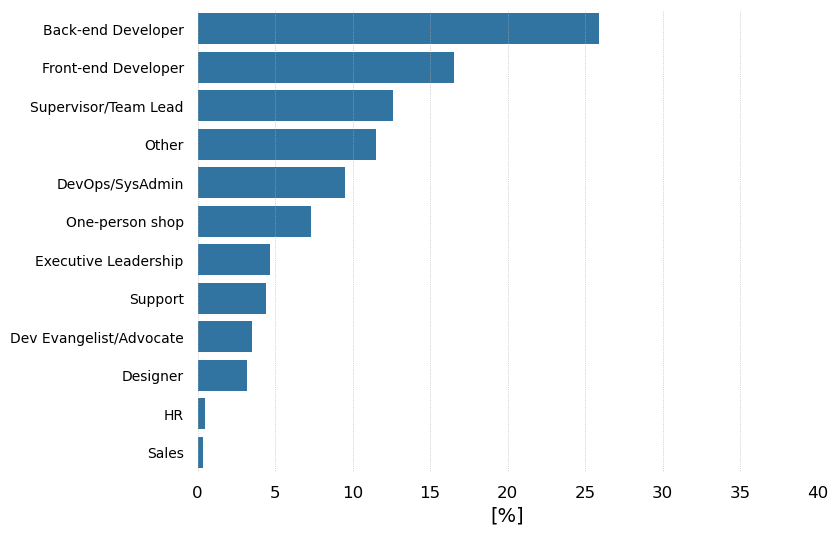

In [21]:
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(roles, orient="h", ax=ax)
ax.grid(True, linewidth=0.5, linestyle=":", axis="x")
ax.set_xticks(np.arange(0,45,5))
ax.set_xticklabels(ax.get_xticks(), fontsize=12)
ax.set_ylabel(None)
ax.set_xlabel("[%]", fontsize=14)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)

In [22]:
encoder = OrdinalEncoder(categories=[["Never", "Sometimes", "Always"]])
df_explore["Do you work remotely?"] = encoder.fit_transform(df_explore[["Do you work remotely?"]]).astype(np.int64)

Text(0, 0.5, '[%]')

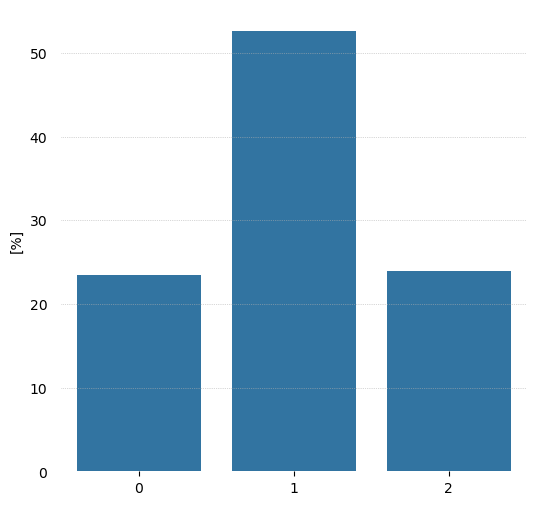

In [23]:
fig, ax = plt.subplots(figsize=(6,6))
sns.countplot(df_explore, x="Do you work remotely?", stat="percent", ax=ax)

ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_xlabel(None)
ax.set_ylabel("[%]")

In [24]:
willing_toshare_mental_issue = df[df["Do you think that discussing a mental health disorder with your employer would have negative consequences?"]!= "Not applicable"]
n_samples, _ = willing_toshare_mental_issue.shape
print(n_samples)
willing_toshare_mental_issue["Do you think that discussing a mental health disorder with your employer would have negative consequences?"].value_counts() / n_samples

1146


Do you think that discussing a mental health disorder with your employer would have negative consequences?
Maybe    0.424956
No       0.382199
Yes      0.192845
Name: count, dtype: float64

In [25]:
willing_to_share_physical_issue = df[df["Do you think that discussing a physical health issue with your employer would have negative consequences?"]!= "Not applicable"]
n_samples, _ = willing_to_share_physical_issue.shape
print(n_samples)
willing_to_share_physical_issue["Do you think that discussing a physical health issue with your employer would have negative consequences?"].value_counts() / n_samples

1146


Do you think that discussing a physical health issue with your employer would have negative consequences?
No       0.730366
Maybe    0.233857
Yes      0.035777
Name: count, dtype: float64

## Feature selection

Pairwise $\chi^2$ tests and _Cramer's V_ statistic were used to identify highly associated features.  
As observed during the data cleaning, the missing values are not at random, they were driven by the survey design, e.g., questions conditional on _current_ or _previous_ employment.

The high values of Cramer's V in many cases, confirmed that the missingness carries meaningful information, for this reason, automatic feature selection based on the $\chi^2$ test results is avoided.  
Instead, features with high redundancy / strong association are reviewed and removed manually.

In [26]:
categorical_columns = [col for col in df.columns if col != "What is your age?"]
results = []
for col1, col2 in combinations(categorical_columns, 2):
    table = pd.crosstab(df[col1], df[col2])
    chi2, pvalue, _, _ = chi2_contingency(table)
    v = association(table, method="cramer")
    result = {
        "feature1" : col1,
        "feature2" : col2,
        "chi2" : chi2,
        "pvalue" : pvalue,
        "cramers_v" : v
    }
    results.append(result)

In [27]:
results_df = pd.DataFrame(results).sort_values(by="cramers_v", ascending=False)
results_df

,feature1,feature2,chi2,pvalue,cramers_v
529,Do you have previous employers?,Was your anonymity protected if you chose to t...,1413.000000,1.048757e-304,1.000000
528,Do you have previous employers?,Did your previous employers provide resources ...,1413.000000,4.449044e-306,1.000000
527,Do you have previous employers?,Did your previous employers ever formally disc...,1413.000000,1.048757e-304,1.000000
4,Are you self-employed?,Has your employer ever formally discussed ment...,1413.000000,4.449044e-306,1.000000
5,Are you self-employed?,Does your employer offer resources to learn mo...,1413.000000,4.449044e-306,1.000000
...,...,...,...,...,...
227,Has your employer ever formally discussed ment...,Do you have a family history of mental illness?,1.722093,9.434029e-01,0.024686
465,Would you feel comfortable discussing a mental...,What is your gender?,1.552680,9.559187e-01,0.023440
537,Do you have previous employers?,Would you bring up a mental health issue with ...,0.394192,8.211117e-01,0.016703
32,Are you self-employed?,Do you have a family history of mental illness?,0.380661,8.266860e-01,0.016413


In [28]:
redundant = results_df[results_df["cramers_v"] > 0.5][["feature1", "feature2", "cramers_v"]]
for i, s in redundant.iterrows():
    print(s["feature1"], "--", s["feature2"])
    print()

Do you have previous employers? -- Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?

Do you have previous employers? -- Did your previous employers provide resources to learn more about mental health issues and how to seek help?

Do you have previous employers? -- Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?

Are you self-employed? -- Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?

Are you self-employed? -- Does your employer offer resources to learn more about mental health concerns and options for seeking help?

Are you self-employed? -- Do you think that discussing a physical health issue with your employer would have negative consequences?

Do you have previous employers? -- Do you think that discussing a physical health 

## Gower Distance

To be able to apply Dimensionality Reduction techniques to the data to get a better sense of it and be able to visualize it, the observations need to be transformed into distance metrics.  
The dataset includes mix data type: numeric, nominal and ordinal, to deal with this we use the Gower distance.

As a didactic exercise, the calculation of the Gower matrix has been implemented from scratch using numpy.  
Once the distance matrix has been calculated the data will be visualized using _Multidimensional Scaling_.

The idea of _Gower's distance_ is to measure how similar (or dissimilar) two observations are when the dataset contains _mixed types of variables_, such as numeric, ordinal, and categorical features.  
Gower's distance calculates a similarity score that is feature-specific and then combines the score for each feature into a single measure.

- __Numeric variables and ordinal variables__  
  The similarity between two observations is based on the absolute difference between the values of the observations for the respective feature, normalized by the range of the variable.

- __Nominal categorical variables__
  The similarity is __1__ if if both observations belong to the same category and __0__ if they belong to different categories.

The overall distance between the $i$ and $j$ observations is given by:

$$
\mathbf{D_{ij}} = 1 - \mathbf{S_{ij}}
$$

Where:  

- $\mathbf{S_{ij}}$ represents the overall similarity score between the observations $i$ and $j$ in the dataset.

The similarity score $\mathbf{S_{ij}}$ is calculated as:

$$
\mathbf{S_{ij}} = \frac{\sum_{k=1}^{p}( w_{ijk} \cdot s_{ijk})}{\sum_{k=1}^{p} w_{ijk}}
$$

Where:  

- $i$ and $j$ refer to the $i^{th}$ and $j^{th}$ observations in the dataset.
- $k$ refers to the index of the feature (the column in the dataset). 
- $s_{ijk}$ refers to the similarity score for the $i^{th}$ and $j^{th}$ observations, which is calculated depending on the data type of the feature $k$.  
- $w_{ijk}$ refers to the weight assigned to the similarity score. $w_{ijk} = 1$ for the features that can be compared and $w_{ijk} = 0$ for the ones that cannot be compared.

Missing values are handled automatically in this formulation, if one of both observations have a missing value for a feature $k$, they cannot be compared so the weight $w_{ijk} = 0$.

### Calculation of the similarity scores

1. For numerical and ordinal variables

$$
s_{ijk} = 1 - \frac{|x_{ik} - x_{jk}|}{max(x_k) - min(x_k)}
$$

2. For nominal variables

$$
s_{ijk} =
\begin{cases}
1, & \text{if } x_{ik} = x_{jk} \\
0, & \text{if } x_{ik} \neq x_{jk}
\end{cases}
$$

### Notes

In the implementation presented here, the edge case where one or more rows contain all NaN values, the returned matrix will show 1's for the corresponding row and column.

In [29]:
to_drop = [
    'Are you self-employed?',
    'Do you have previous employers?',
    'Have you had a mental health disorder in the past?',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
    'Were you aware of the options for mental health care provided by your previous employers?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'
]

In [30]:
df_reduced = df.drop(to_drop, axis=1)
df_reduced.shape

(1413, 34)

In [31]:
nominal_cols = [
    'Are you self-employed?',
    'How many employees does your company or organization have?',
    'Is your employer primarily a tech company/organization?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Do you know the options for mental health care available under your employer-provided coverage?',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
    'Do you feel that your employer takes mental health as seriously as physical health?',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?',
    'Do you have previous employers?',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
    'Have your previous employers provided mental health benefits?',
    'Were you aware of the options for mental health care provided by your previous employers?',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?',
    'Did you feel that your previous employers took mental health as seriously as physical health?',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?',
    'Would you bring up a mental health issue with a potential employer in an interview?',
    'How willing would you be to share with friends and family that you have a mental illness?',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?',
    'Do you have a family history of mental illness?',
    'Have you had a mental health disorder in the past?',
    'Do you currently have a mental health disorder?',
    'Have you been diagnosed with a mental health condition by a medical professional?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?',
    'Which of the following best describes your work position?',
    'What is your gender?'
]

ordinal_cols = {
    'Do you feel that being identified as a person with a mental health issue would hurt your career?' : ['No, it has not', "No, I don't think it would", 'Maybe', 'Yes, I think it would', 'Yes, it has'],
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?' : ['No, they do not', "No, I don't think they would", 'Maybe','Yes, I think they would','Yes, they do'],
    'Do you work remotely?' : ['Never', 'Sometimes', 'Always']
}

numerical_cols = ['What is your age?']

In [32]:
len(nominal_cols) + len(ordinal_cols) + len(numerical_cols)

44

As mentioned above, in the _Feature selection_ section, the missing answers in the dataset represent structure and are not Missing At Random.  
Two alternatives are explored here:

1. Calculation of the distance matrix and Non-Metric MDS using all features, i.e., 44 questions of the dataset.
2. Calculation of the distance matrix and Non-Metric MDS using a reduced number of features, in this case 34 features after manual feature selection.

### All questions included

In [33]:
D = gower_matrix(
    df,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numerical_cols=numerical_cols,
    as_frame=True
)

In [34]:
is_valid_dm(D)

True

In [ ]:
mds = MDS(
    n_components=2,
    metric_mds=False,
    n_init=10,
    max_iter=500,
    metric="precomputed",
    init="random",
)

In [ ]:
D_transformed = mds.fit_transform(D)

In [ ]:
D_transformed

In [ ]:
# Store the transformed data
# This cell takes a long time to run
pd.DataFrame(D_transformed, columns=["feature1", "feature2"]).to_csv(DATA_UTILS.joinpath("NMDS_full.csv"), sep=";", index=False)

In [35]:
# Load the NMDS using all features
D_transformed = pd.read_csv(DATA_UTILS.joinpath("NMDS_full.csv"), sep=";").values

In [36]:
D_transformed

array([[ 0.14143929, -0.21343889],
       [ 0.25386607,  0.48673711],
       [ 0.07206256, -0.39035563],
       ...,
       [-0.11507064,  0.66567404],
       [-0.20310104,  0.07216626],
       [ 0.91754782,  0.28902466]], shape=(1413, 2))

### After manual feature selection

In [37]:
D_reduced = gower_matrix(
    df_reduced,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numerical_cols=numerical_cols,
    as_frame=True
)

In [38]:
is_valid_dm(D_reduced)

True

In [ ]:
mds_reduced = MDS(
    n_components=2,
    metric_mds=False,
    n_init=10,
    max_iter=500,
    metric="precomputed",
    init="random"
)

In [ ]:
D_transformed_reduced = mds_reduced.fit_transform(D_reduced)

In [ ]:
D_transformed_reduced

In [ ]:
pd.DataFrame(D_transformed_reduced, columns=["feature1", "feature2"]).to_csv(DATA_UTILS.joinpath("NMDS_reduced.csv"), sep=";", index=False)

In [39]:
# Load the NMDS using reduced
D_transformed_reduced = pd.read_csv(DATA_UTILS.joinpath("NMDS_reduced.csv"), sep=";").values

In [40]:
D_transformed_reduced

array([[-0.34841639,  0.20781179],
       [-0.31893282, -0.41811664],
       [-0.08376952,  0.40954944],
       ...,
       [ 0.41788239, -0.42827393],
       [ 0.14535322, -0.39257303],
       [-0.84206418, -0.13187012]], shape=(1413, 2))

## 4. Visualization

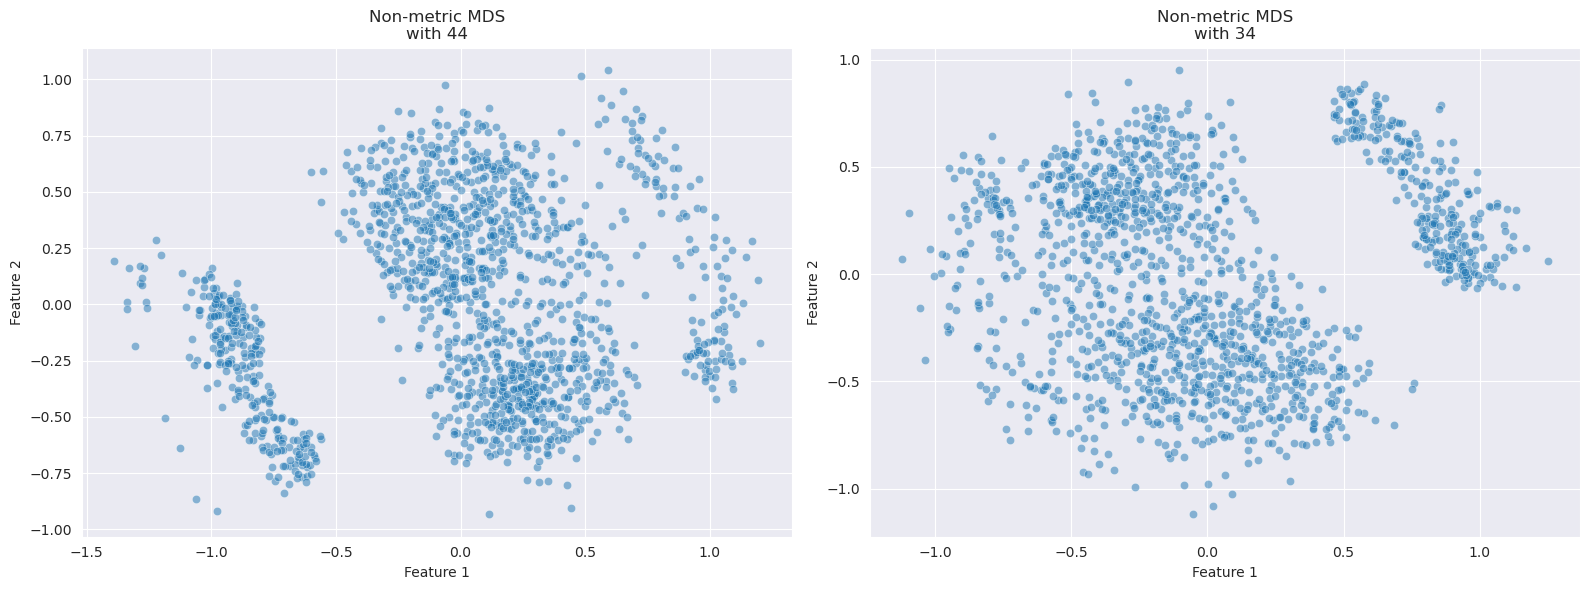

In [41]:
_, n_features = df.shape
_, n_features_reduced = df_reduced.shape

with sns.axes_style("darkgrid"):
    fig, axs = plt.subplots(figsize=(16,6), nrows=1, ncols=2)

    sns.scatterplot(x=D_transformed[:,0],
                    y=D_transformed[:,1],
                    alpha=0.5,
                    ax=axs[0])
    axs[0].set_title(f"Non-metric MDS\nwith {n_features}")
    
    sns.scatterplot(x=D_transformed_reduced[:,0],
                    y=D_transformed_reduced[:,1],
                    alpha=0.5,
                    ax=axs[1])
    axs[1].set_title(f"Non-metric MDS\nwith {n_features_reduced}")
    
    for ax in axs:
        ax.set_xlabel(r"Feature 1")
        ax.set_ylabel(r"Feature 2")
        
fig.tight_layout()    

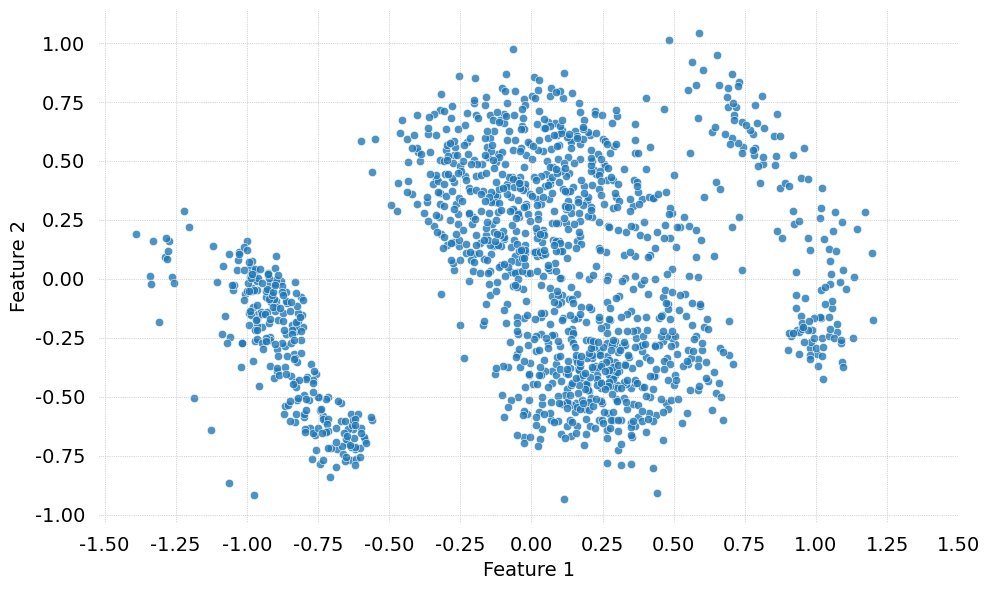

In [42]:
fig, ax = plt.subplots(figsize=(10,6), nrows=1, ncols=1)

sns.scatterplot(x=D_transformed[:,0],
                y=D_transformed[:,1],
                alpha=0.8,
                ax=ax)

#ax.set_title("NMDS visualization of the \nOSMI Mental Health in Tech Survey 2016")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xticks(np.arange(-1.5,1.75,0.25))
ax.set_xticklabels([f"{tick:.2f}" for tick in ax.get_xticks()], fontsize=14)
ax.set_yticks(np.arange(-1,1.25,0.25))
ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=14)
ax.tick_params(axis="both", length=0, pad=10)
ax.set_xlabel(r"Feature 1", fontsize=14)
ax.set_ylabel(r"Feature 2", fontsize=14)
    
fig.tight_layout()    

In [43]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_,
         model.distances_,
         counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

### Mantel test

To assess whether the manual feature selection altered the structure of the data, a Mantel test is performed between _D_ and _D_reduced_.  

The _Mantel_ test compares two distance matrices (in this case _D_ and _D_reduced_) by calculating the correlation between the distances in the lower or open triangular portions of the matrices.
The test calculates the $r_M$ statistic given two distances matrices:

$$
r_{M} = \frac{1}{d-1} \sum_{i=1}^{n-1} \sum_{j=i+1}^{n} \text{stand}(D_X)_{ij} \text{ stand}(D_Y)_{ij}
$$

where:

$$
d = \frac{n(n-1)}{2}
$$

where:

- $n$ is the number of rows/columns of each of the distance matrices.
- $\text{stand}(D_X)_{ij} \text{ stand}(D_Y)_{ij}$ are the distance matrices with ther _upper triangules_ containing the standardized distances.

Mantel tests:

_Null hypothesis_ $H_0$ that there is no linear correlation between the two distance matrices. 
_Alternative hypothesis_ $H_a$: There distance matrices are lineraly correlated.

In [44]:
gower = DistanceMatrix(D)

gower_reduced = DistanceMatrix(D_reduced)

r, pvalue, n = mantel(
    gower,
    gower_reduced,
    method="pearson"
)

In [45]:
r

np.float64(0.9611083461749119)

In [46]:
pvalue

np.float64(0.001)

### Clusters

In [47]:
model_complete = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="complete",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D)

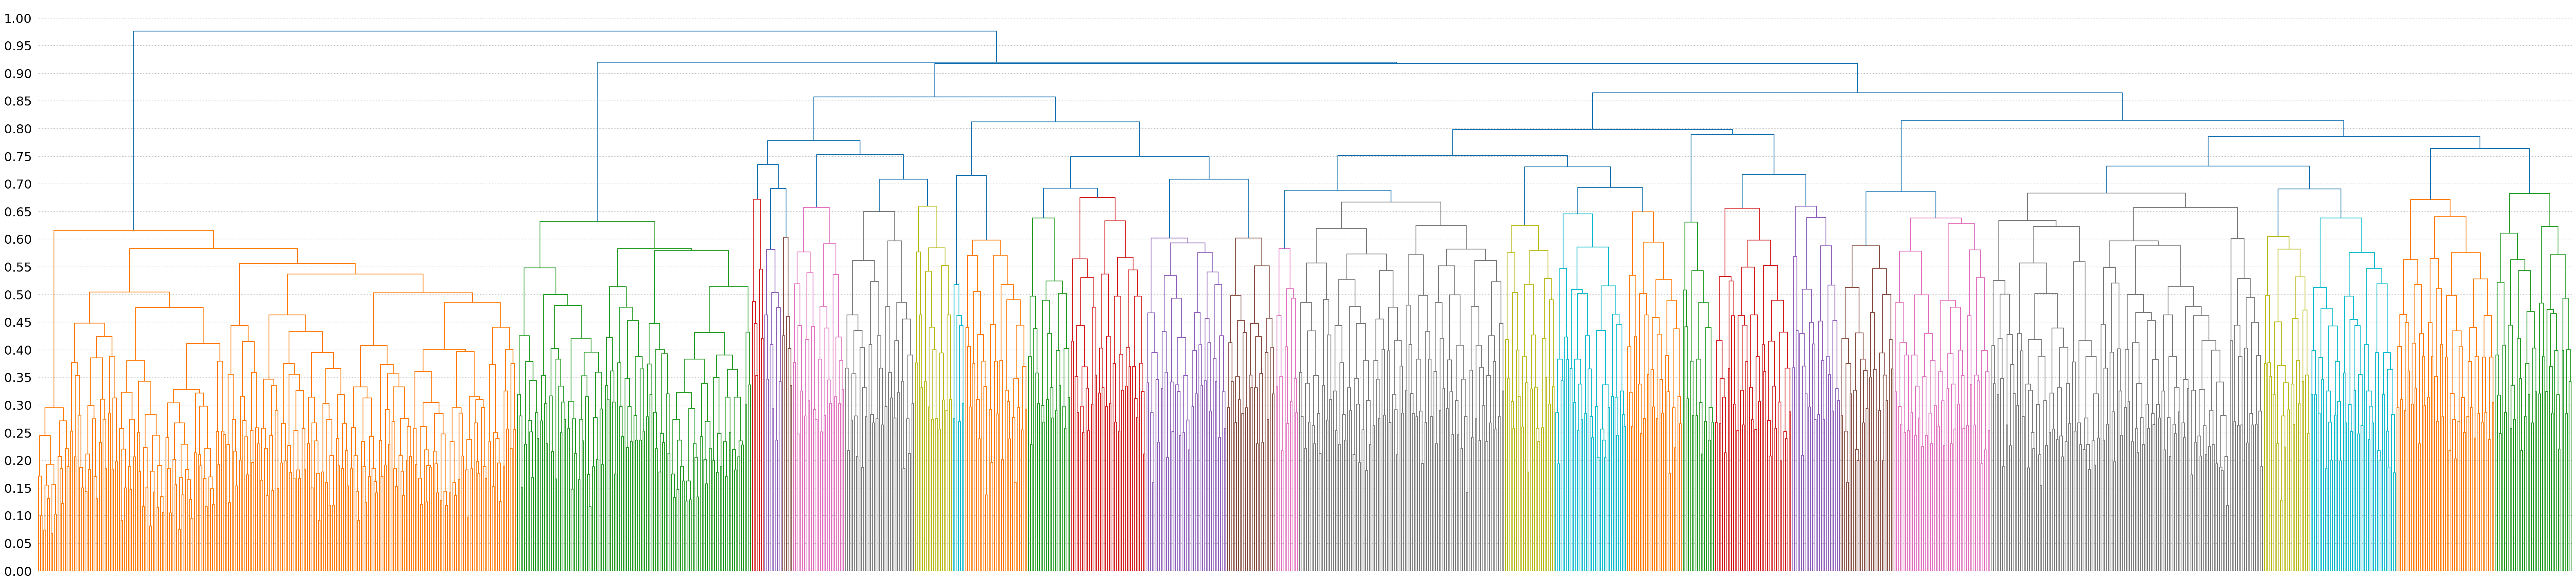

In [48]:
fig, ax = plt.subplots(figsize=(80,18))
plot_dendrogram(model_complete, ax=ax)
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.05,.05))
ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=22)
ax.tick_params(axis='x', bottom=False, labelbottom=False)

In [49]:
model_complete_reduced = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="complete",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D_reduced)

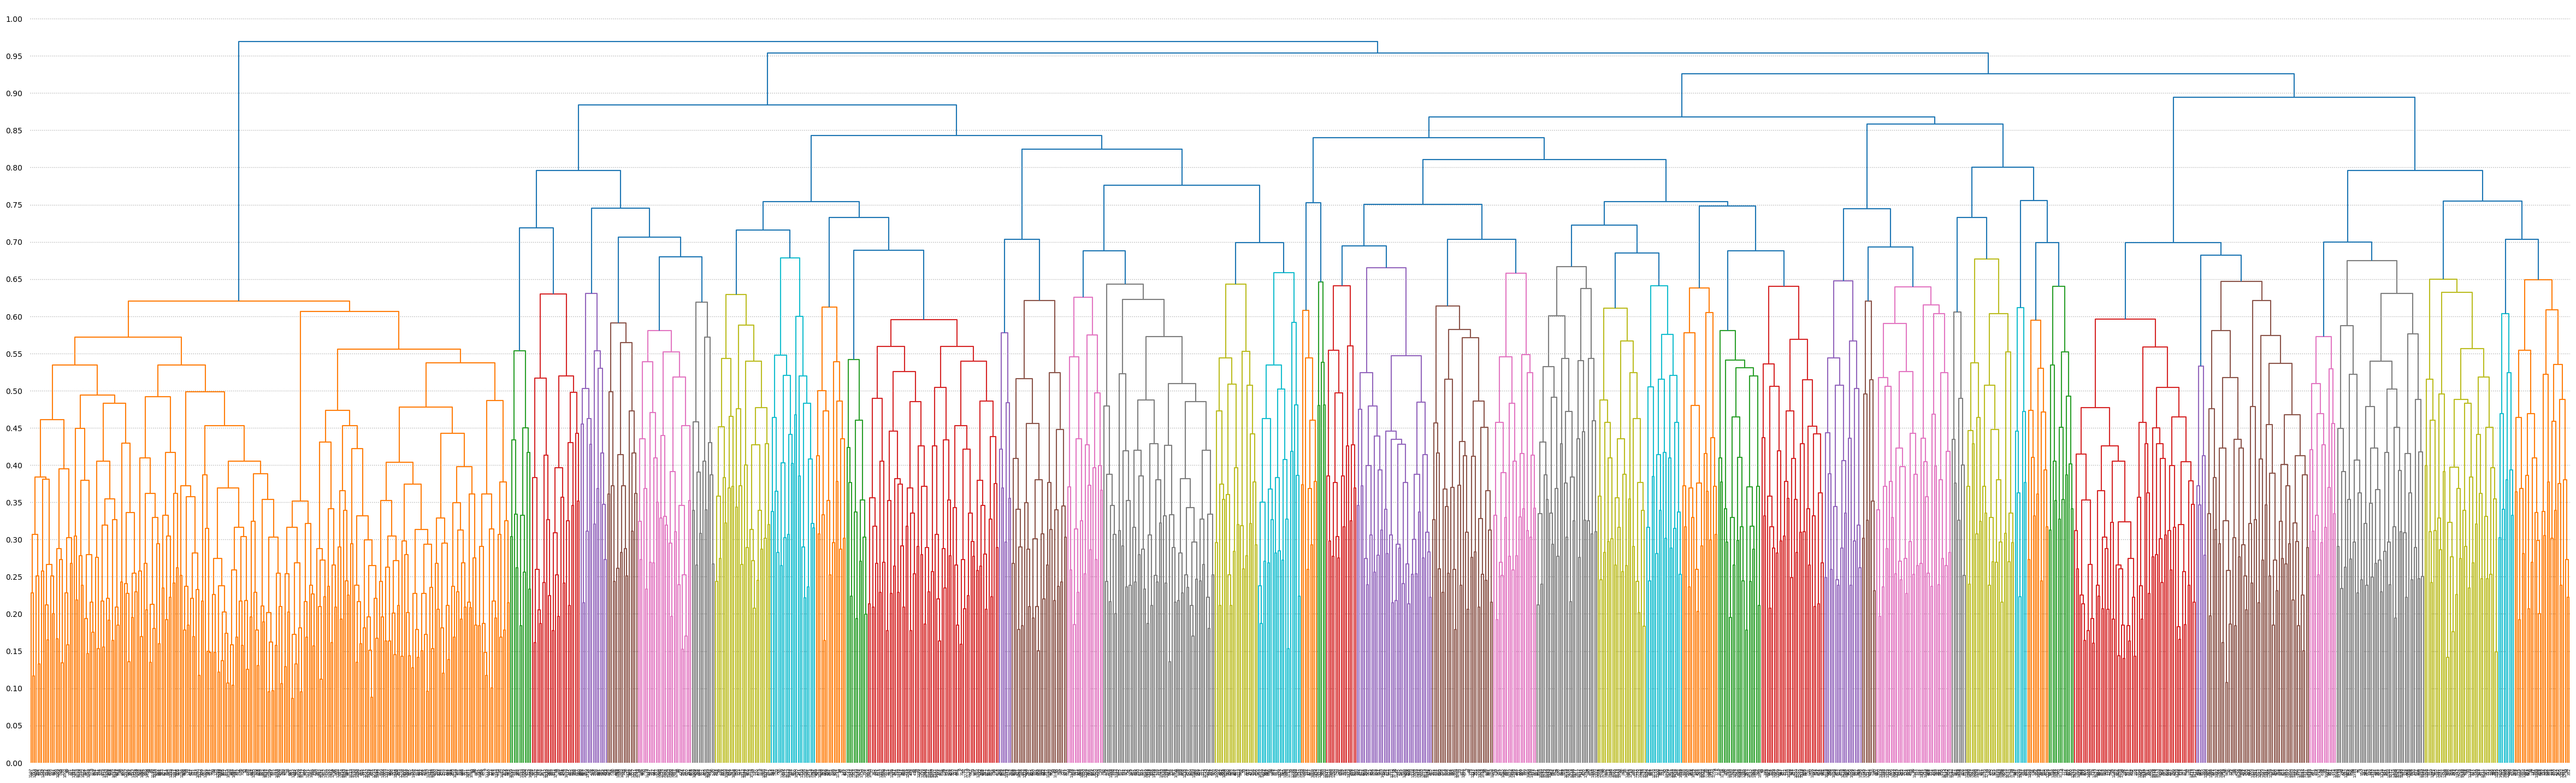

In [50]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_complete_reduced, ax=ax)

In [51]:
model_average = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="average",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D)

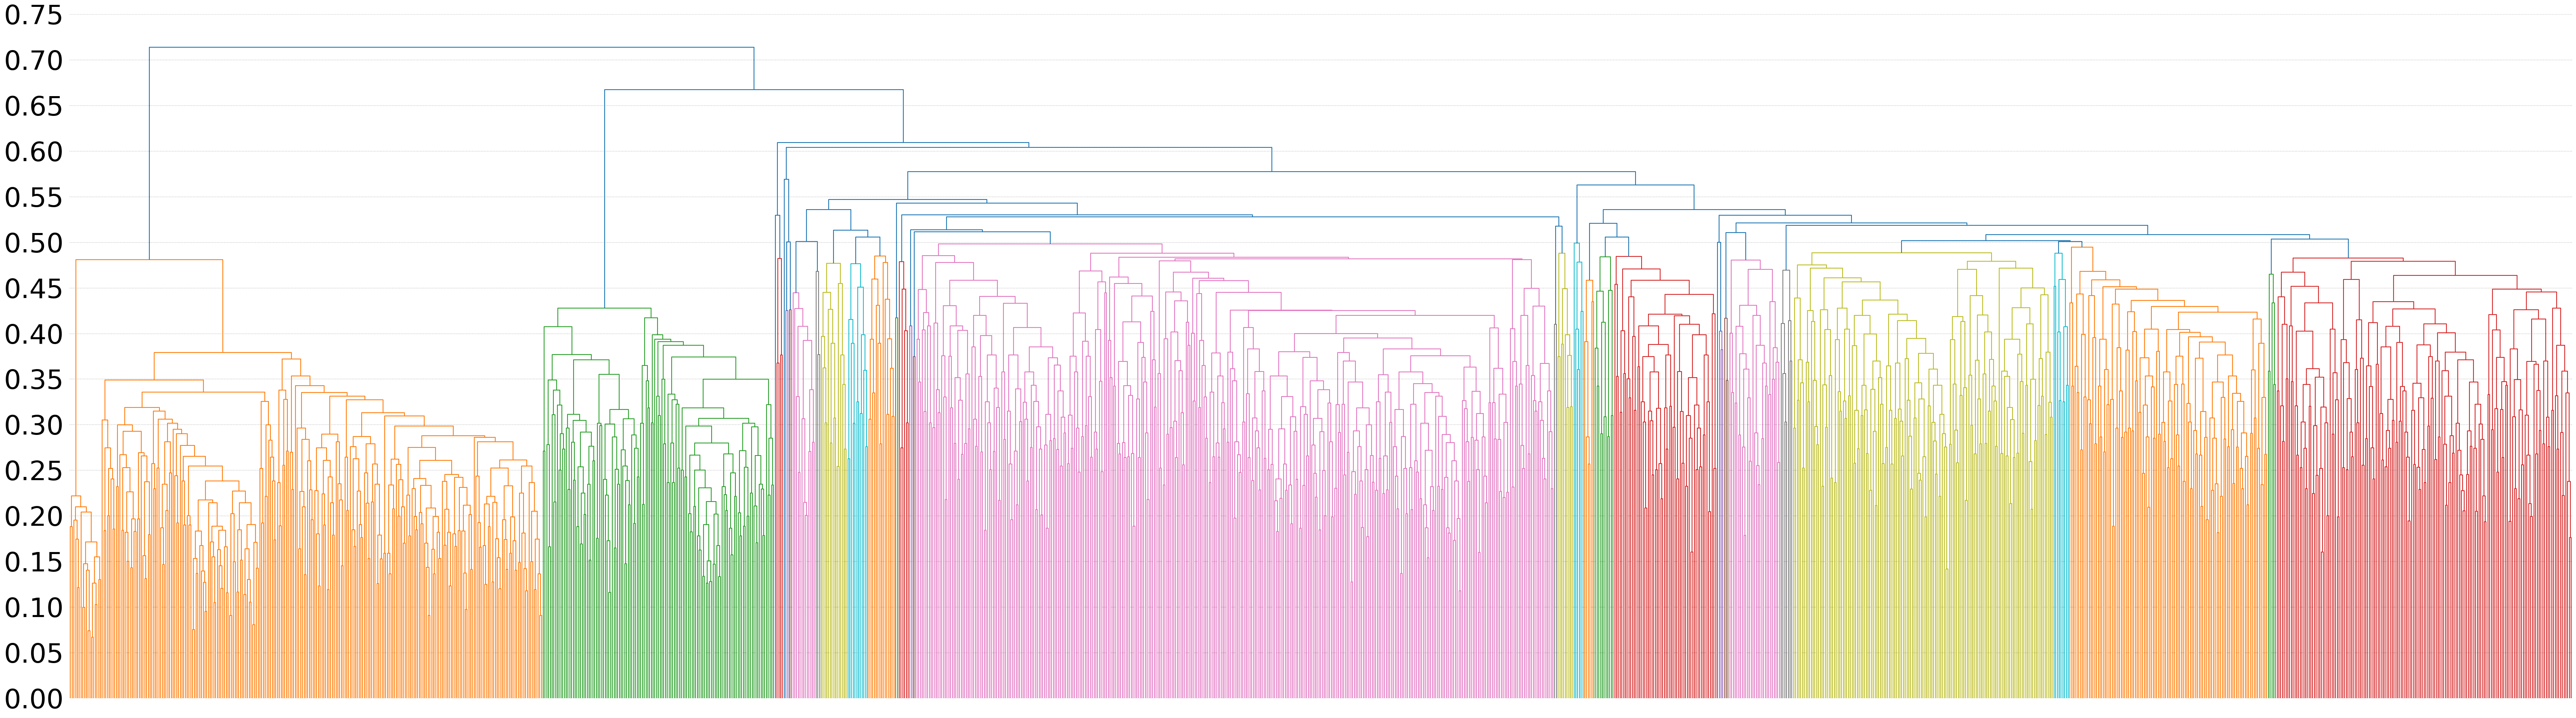

In [52]:
fig, ax = plt.subplots(figsize=(80,22))
plot_dendrogram(model_average, ax=ax)
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,0.8,.05))
ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=48)
ax.tick_params(axis='x', bottom=False, labelbottom=False)

In [53]:
model_average_reduced = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="average",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D_reduced)

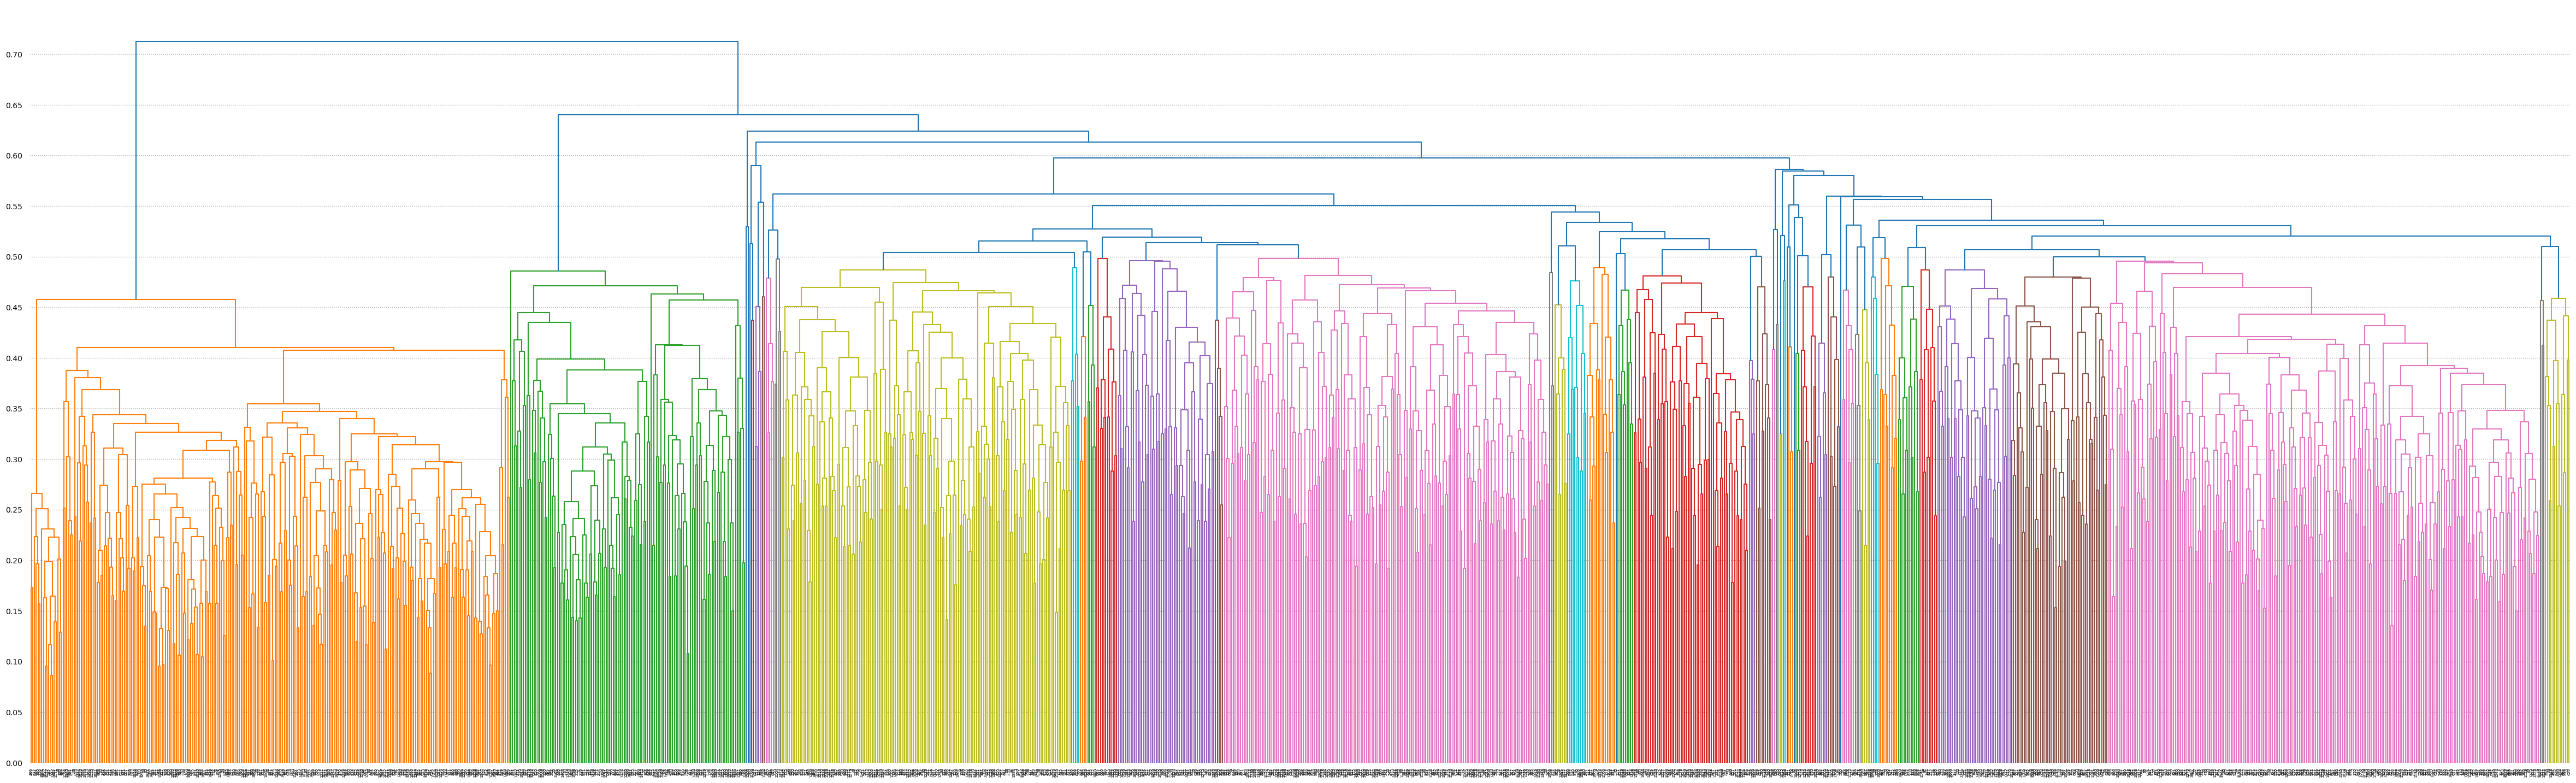

In [54]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_average_reduced, ax=ax)

In [55]:
model_single = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="single",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D)

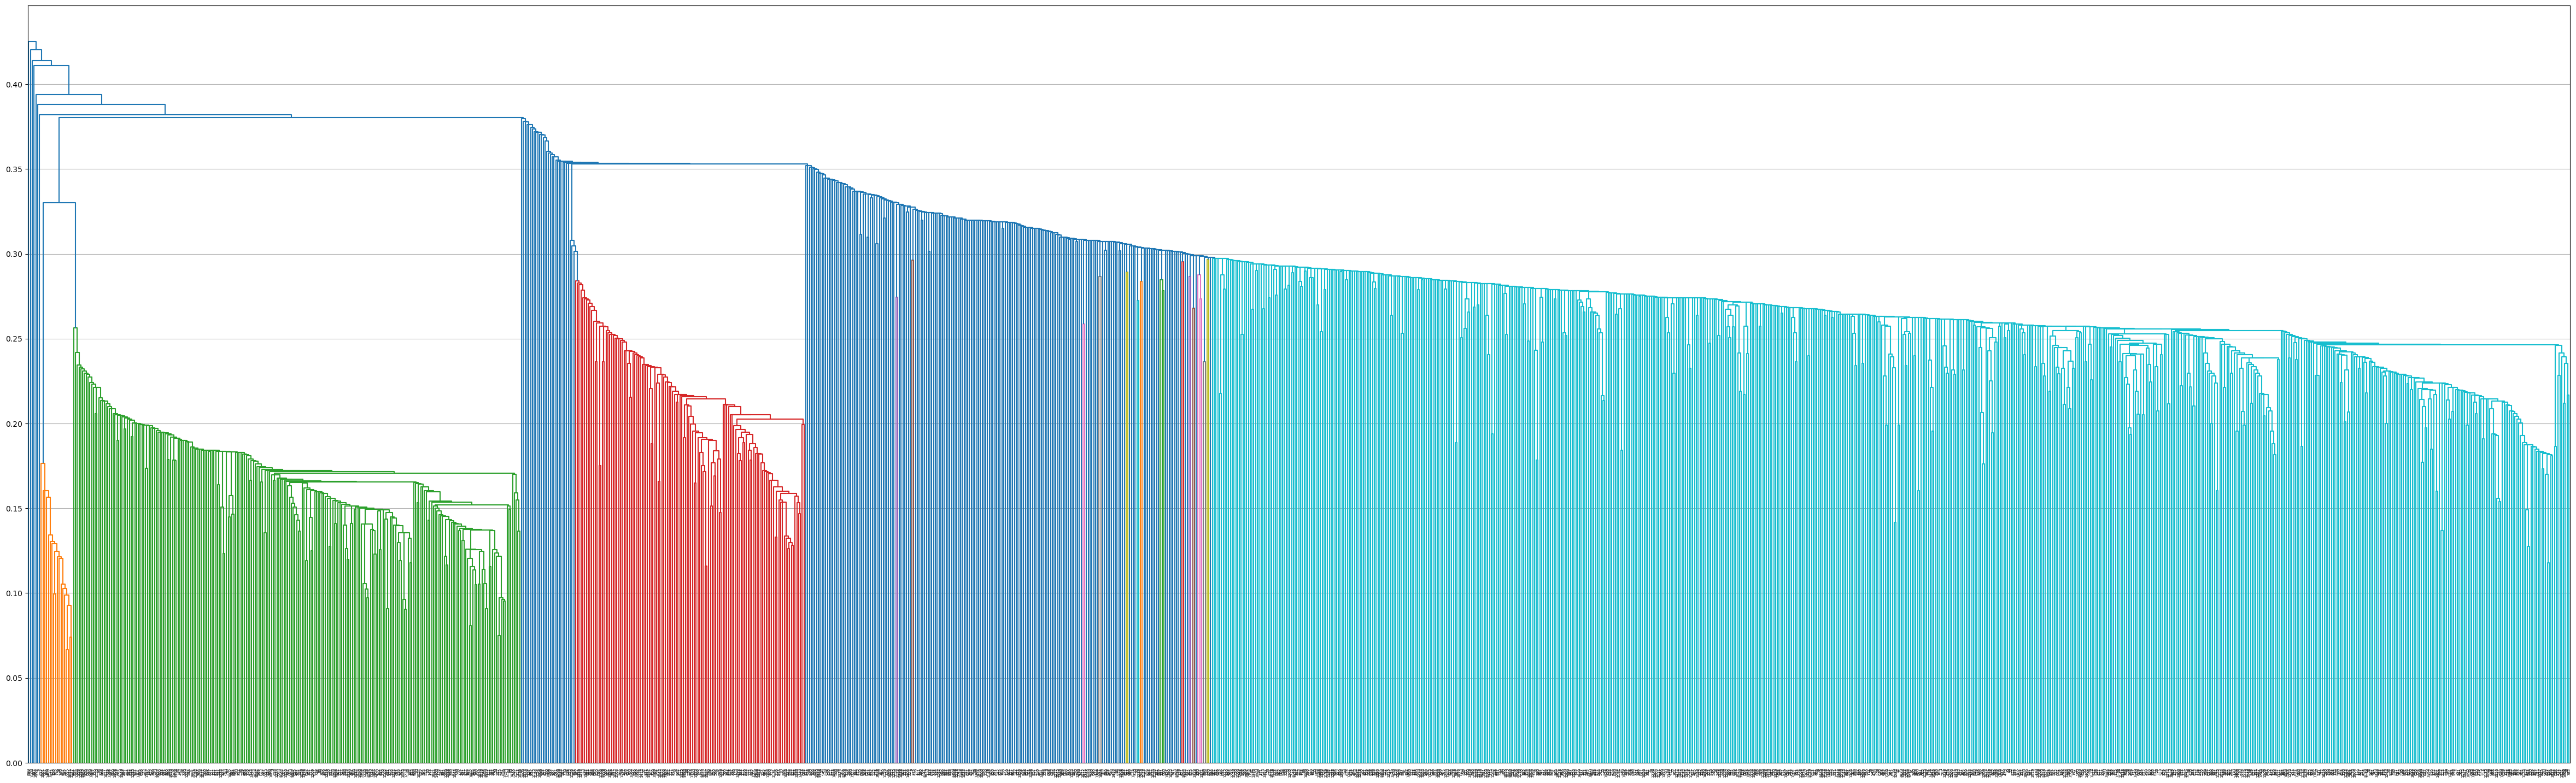

In [56]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, axis="y")
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_single, ax=ax)

In [57]:
model_single_reduced = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="single",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D_reduced)

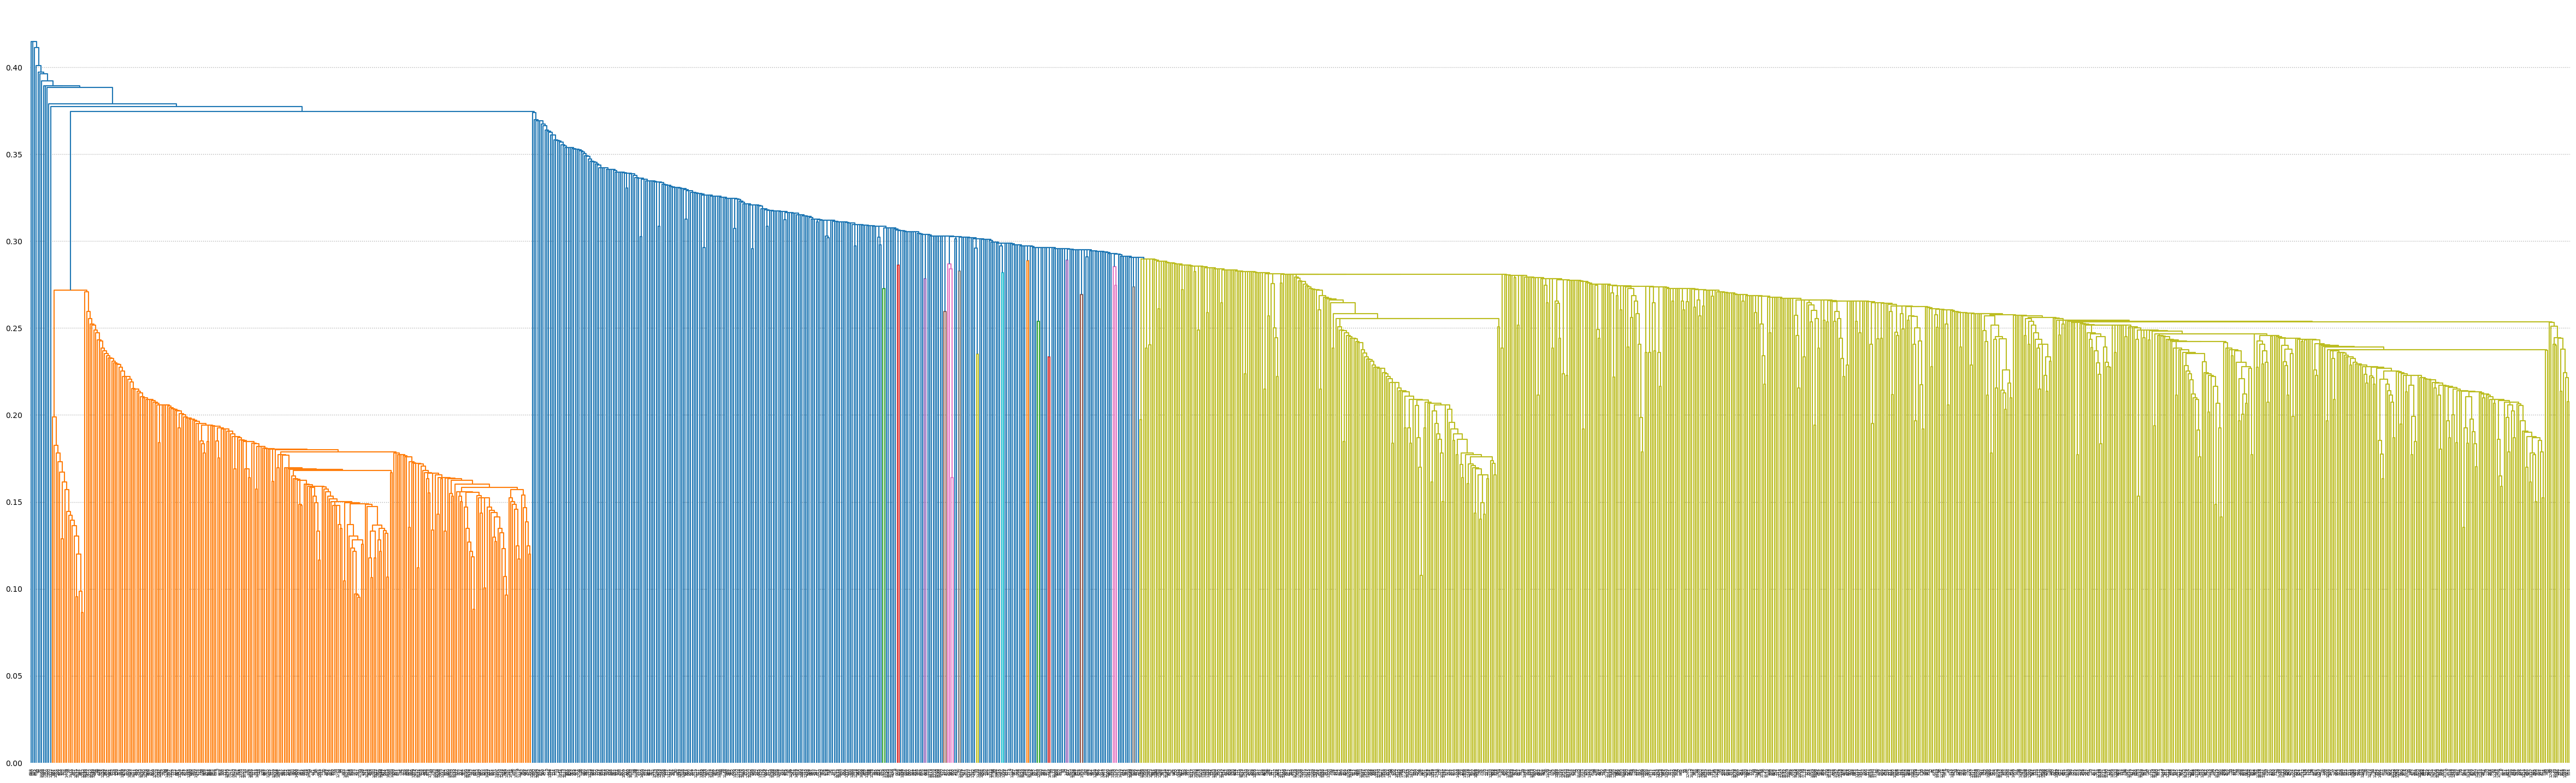

In [58]:
ig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_single_reduced, ax=ax)

### Clusters visualization

In [59]:
models = {
    "complete" : model_complete,
    "average" : model_average,
    "single" : model_single,
    "complete_reduced" : model_complete_reduced,
    "average_reduced" : model_average_reduced,
    "single_reduced" : model_single_reduced
}

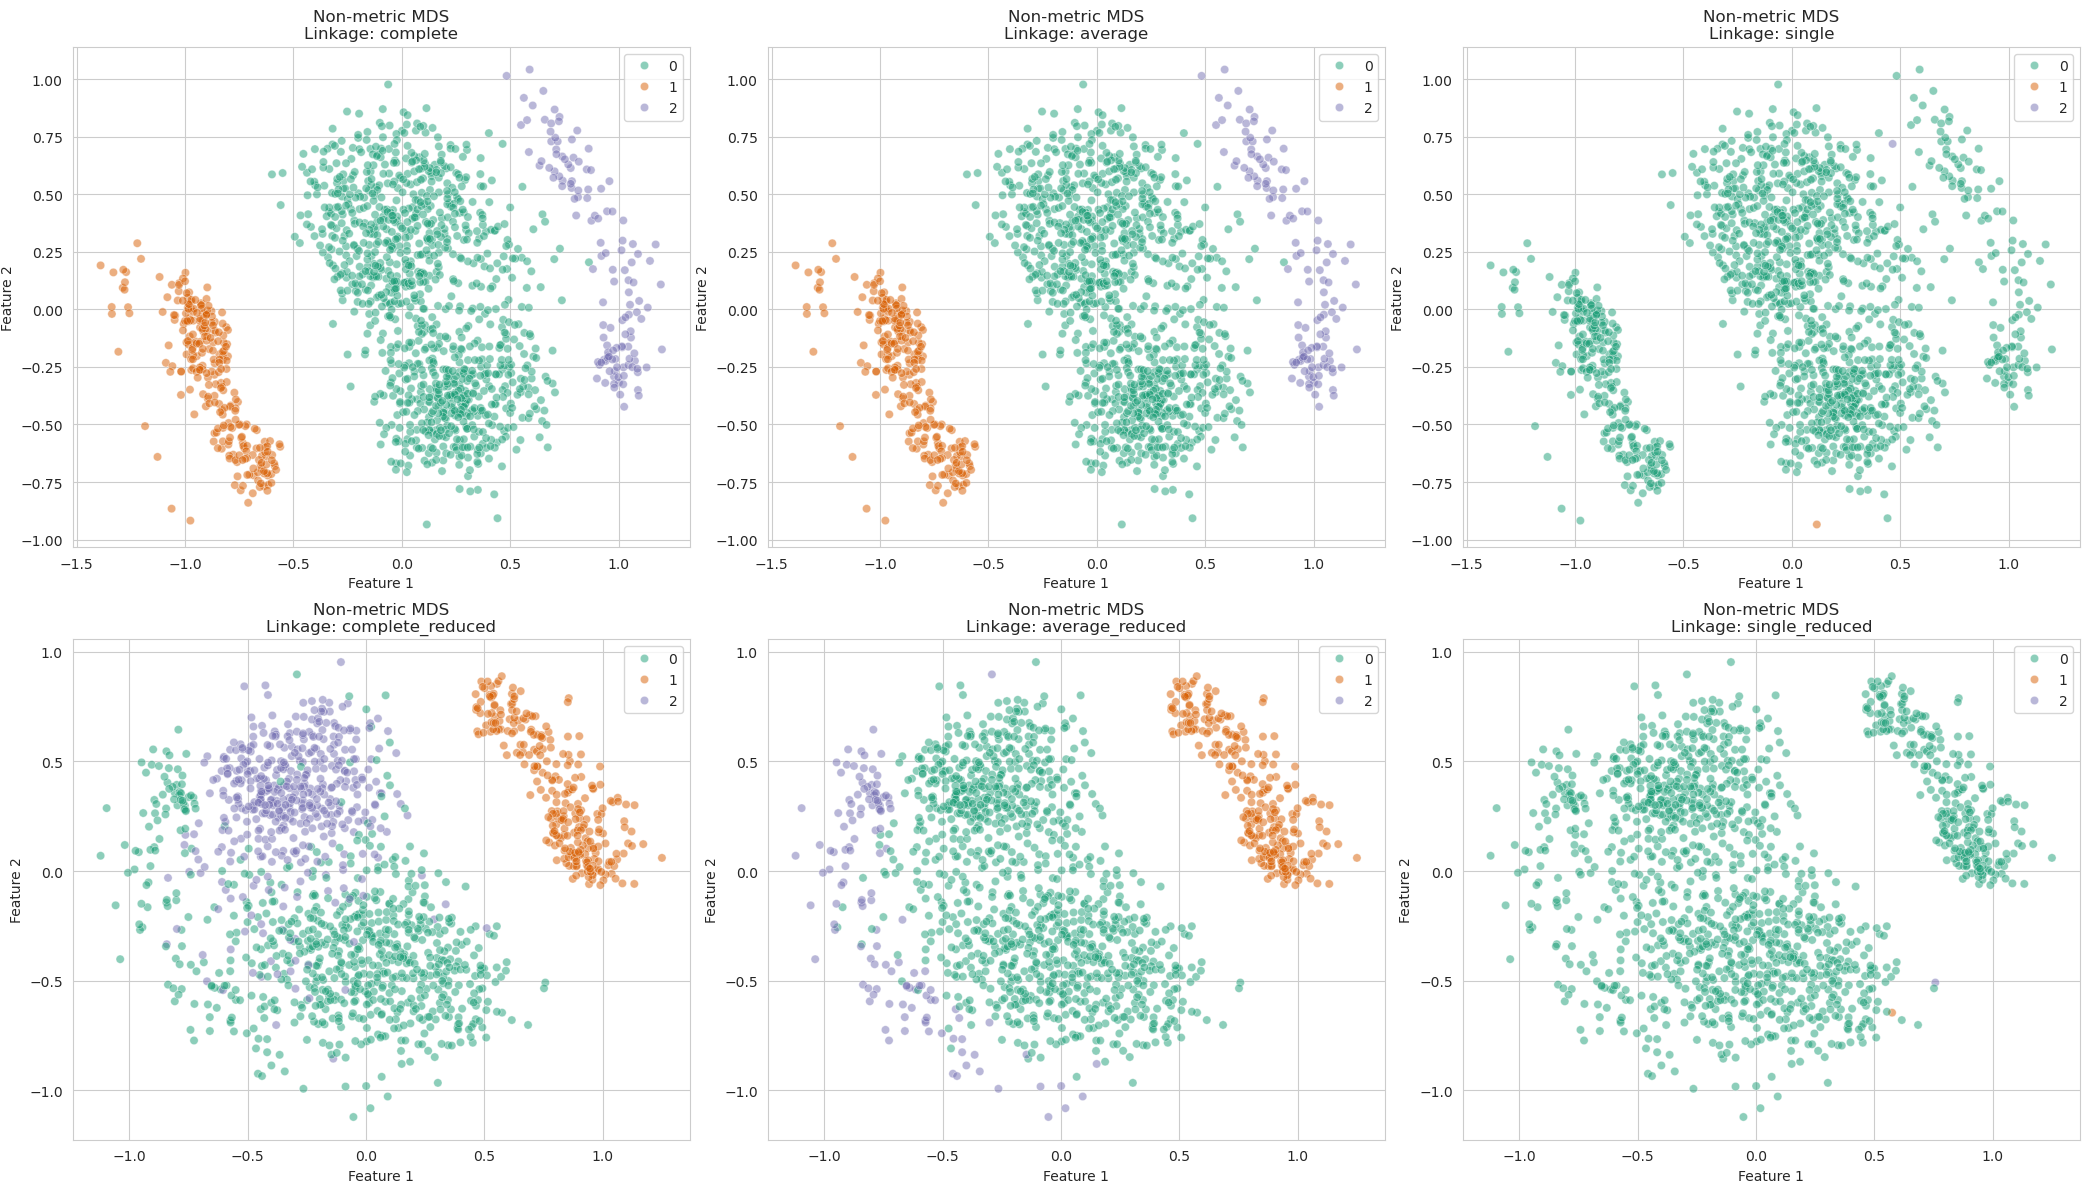

In [60]:
with sns.axes_style("whitegrid"):
    fig, axs = plt.subplots(figsize=(21,12), nrows=2, ncols=3)
    for model, ax in zip(models.keys(), axs.flatten()):
        ax.set_title(f"Non-metric MDS\nLinkage: {model}")
        ax.set_xlabel(r"Feature 1")
        ax.set_ylabel(r"Feature 2")
        if "reduced" in model:
            sns.scatterplot(x=D_transformed_reduced[:,0],
                            y=D_transformed_reduced[:,1],
                            alpha=0.5, hue=models[model].labels_,
                            palette="Dark2",
                            ax=ax)
        else:
            sns.scatterplot(x=D_transformed[:,0],
                            y=D_transformed[:,1],
                            alpha=0.5,
                            hue=models[model].labels_,
                            palette="Dark2",
                            ax=ax)
    fig.tight_layout()

### Compare clusters formed with reduced features

In [61]:
# ARI between
adjusted_rand_score(model_average.labels_, model_average_reduced.labels_)

1.0

In [62]:
adjusted_rand_score(model_complete.labels_, model_complete_reduced.labels_)

0.35989787469612916

In [63]:
cluster_results = []
cluster_results_reduced = []
for k in [2,3,4,5,6,7,8]:
    for linkage_metric in ["complete", "average"]:
        linkage_full = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage=linkage_metric,
            compute_full_tree=True,
            distance_threshold=None,
            compute_distances=True
        ).fit(D)
        
        cluster_results.append(linkage_full)
        
        linkage_reduced = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage=linkage_metric,
            compute_full_tree=True,
            distance_threshold=None,
            compute_distances=True
        ).fit(D_reduced)

        cluster_results_reduced.append(linkage_reduced)

In [64]:
for full, reduced in zip(cluster_results, cluster_results_reduced):
    print(f"Linkage:\nFull features: {full.linkage}; n_clusters: {full.n_clusters}\nReduced features: {reduced.linkage}; n_clusters {reduced.n_clusters}")
    print(f"ARI: {adjusted_rand_score(full.labels_, reduced.labels_)}")
    print()

Linkage:
Full features: complete; n_clusters: 2
Reduced features: complete; n_clusters 2
ARI: 1.0

Linkage:
Full features: average; n_clusters: 2
Reduced features: average; n_clusters 2
ARI: 1.0

Linkage:
Full features: complete; n_clusters: 3
Reduced features: complete; n_clusters 3
ARI: 0.35989787469612916

Linkage:
Full features: average; n_clusters: 3
Reduced features: average; n_clusters 3
ARI: 1.0

Linkage:
Full features: complete; n_clusters: 4
Reduced features: complete; n_clusters 4
ARI: 0.33115757355088127

Linkage:
Full features: average; n_clusters: 4
Reduced features: average; n_clusters 4
ARI: 0.9856712899851738

Linkage:
Full features: complete; n_clusters: 5
Reduced features: complete; n_clusters 5
ARI: 0.5010558815070929

Linkage:
Full features: average; n_clusters: 5
Reduced features: average; n_clusters 5
ARI: 0.9656119752835739

Linkage:
Full features: complete; n_clusters: 6
Reduced features: complete; n_clusters 6
ARI: 0.45573923167077235

Linkage:
Full features: 

In [65]:
final_clusters = cluster_results[3]

In [66]:
silhouette_scores_average = []
silhouette_scores_complete = []
for linkage in cluster_results:
    if linkage.linkage == "average":
        score = silhouette_score(D, linkage.labels_, metric="precomputed")
        silhouette_scores_average.append(score)
    elif linkage.linkage == "complete":
        score = silhouette_score(D, linkage.labels_, metric="precomputed")
        silhouette_scores_complete.append(score)

Text(0, 0.5, 'Silhoutte score')

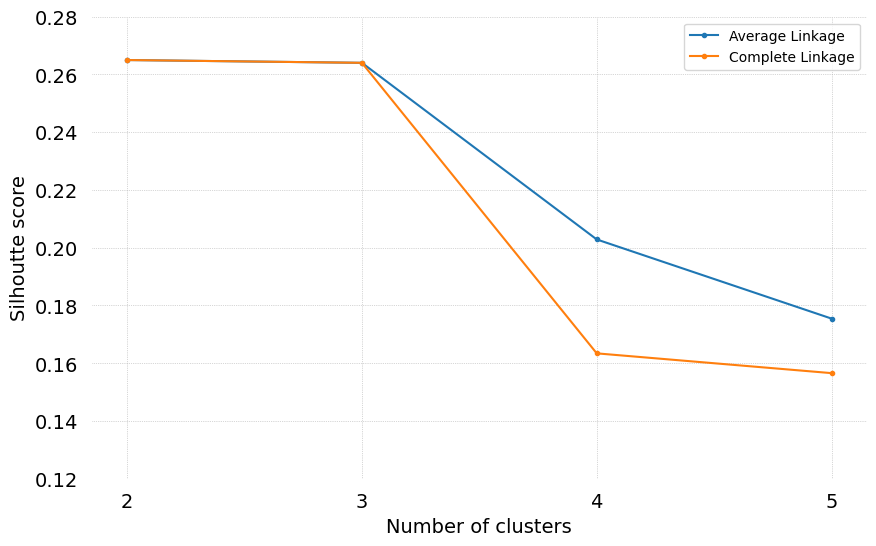

In [67]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(
    np.arange(2,6,1),
    silhouette_scores_average[:4],
    marker='.',
    label="Average Linkage"
)
ax.plot(
    np.arange(2,6,1),
    silhouette_scores_complete[:4],
    marker='.',
    label="Complete Linkage"
)
ax.legend(loc="upper right")
#ax.set_title("Silhouette scores for Average and Complete Linkages")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)
ax.set_xticks(np.arange(2,6,1))
ax.set_xticklabels([f"{tick}" for tick in ax.get_xticks()], fontsize=14)
ax.set_yticks(np.arange(0.12,0.29,0.02))
ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=14)
ax.tick_params(axis="both", length=0, pad=10)
ax.set_xlabel(r"Number of clusters", fontsize=14)
ax.set_ylabel(r"Silhoutte score", fontsize=14)

### Comparing Linkage measures and cluster sizes

In [68]:
linkages = [model for model in cluster_results if model.linkage in ["complete", "average"]]# and model.n_clusters_ <= 5]
average_linkage = [model for model in cluster_results if model.linkage in ["average"]  and model.n_clusters_ <= 5]
complete_linkage = [model for model in cluster_results if model.linkage in ["complete"] and model.n_clusters_ <= 5]

In [69]:
for start in range(0,len(linkages),2):
    linkage_1, linkage_2 = linkages[start:start+2]
    ari = adjusted_rand_score(linkage_1.labels_, linkage_2.labels_)
    print(f"Linkages {linkage_1.linkage}, {linkage_2.linkage}")
    print(f"Cluster size: {linkage_1.n_clusters_}, {linkage_2.n_clusters_}")
    print(f"ARI = {ari}")

Linkages complete, average
Cluster size: 2, 2
ARI = 1.0
Linkages complete, average
Cluster size: 3, 3
ARI = 1.0
Linkages complete, average
Cluster size: 4, 4
ARI = 0.5912274731233982
Linkages complete, average
Cluster size: 5, 5
ARI = 0.3626401905884121
Linkages complete, average
Cluster size: 6, 6
ARI = 0.46204775858945557
Linkages complete, average
Cluster size: 7, 7
ARI = 0.5026756170115388
Linkages complete, average
Cluster size: 8, 8
ARI = 0.5111342121065786


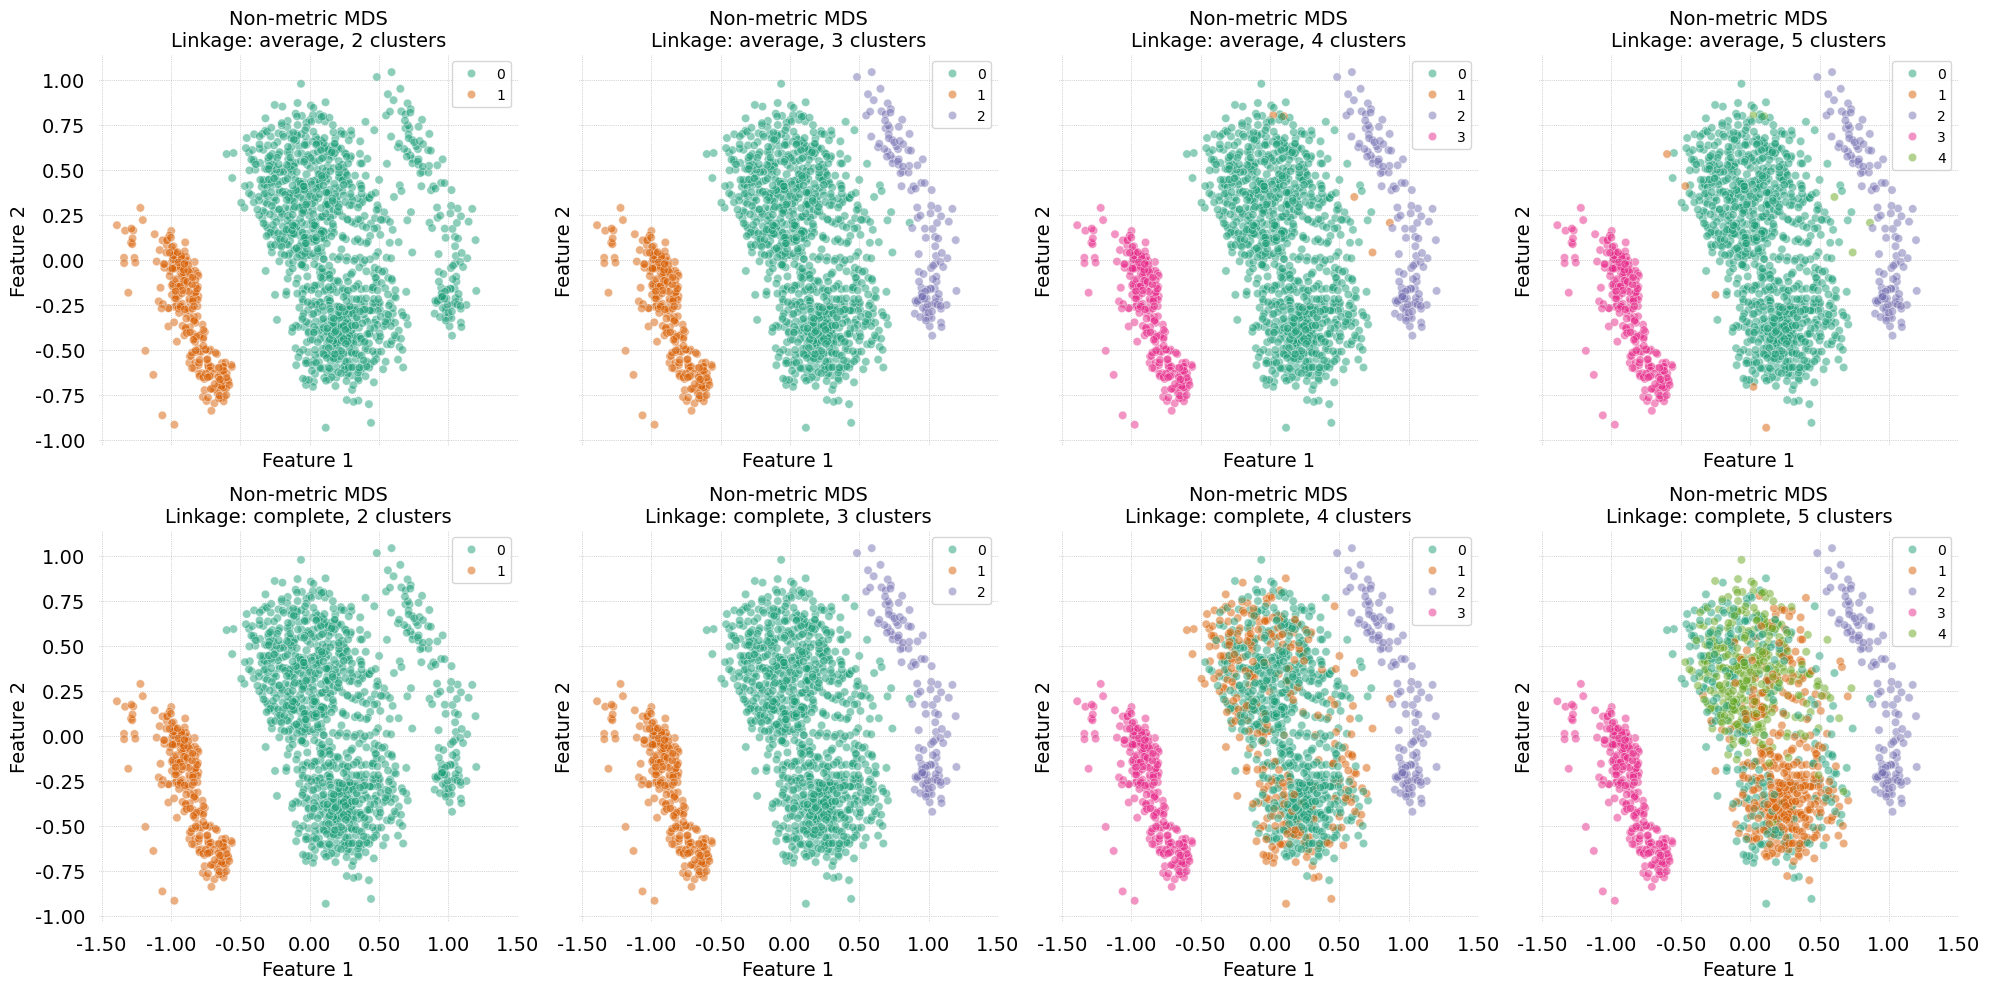

In [70]:
fig, axs = plt.subplots(figsize=(20,10), nrows=2, ncols=4, sharex=True, sharey=True)

for idx, linkage in enumerate(average_linkage):
    
    axs[0, idx].set_title(f"Non-metric MDS\nLinkage: {linkage.linkage}, {linkage.n_clusters_} clusters", fontsize=14)      
    axs[0, idx].set_xlabel(r"Feature 1")
    axs[0, idx].set_ylabel(r"Feature 2") 
    sns.scatterplot(x=D_transformed[:,0],
                    y=D_transformed[:,1],
                    alpha=0.5,
                    hue=linkage.labels_,
                    palette="Dark2",
                    ax=axs[0, idx])

for idx, linkage in enumerate(complete_linkage):
    
    axs[1, idx].set_title(f"Non-metric MDS\nLinkage: {linkage.linkage}, {linkage.n_clusters_} clusters", fontsize=14)      
    axs[1, idx].set_xlabel(r"Feature 1")
    axs[1, idx].set_ylabel(r"Feature 2") 
    sns.scatterplot(x=D_transformed[:,0],
                    y=D_transformed[:,1],
                    alpha=0.5,
                    hue=linkage.labels_,
                    palette="Dark2",
                    ax=axs[1, idx])
    
for ax in axs.flatten():
    ax.grid(True, linestyle=":", linewidth=0.5)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_xticks(np.arange(-1.5,1.75,0.5))
    ax.set_xticklabels([f"{tick:.2f}" for tick in ax.get_xticks()], fontsize=14)
    ax.set_yticks(np.arange(-1,1.25,0.25))
    ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=14)
    ax.tick_params(axis="both", length=0, pad=10)
    ax.set_xlabel(r"Feature 1", fontsize=14)
    ax.set_ylabel(r"Feature 2", fontsize=14)
fig.tight_layout()

### Final Visualization

Text(0, 0.5, 'Feature 2')

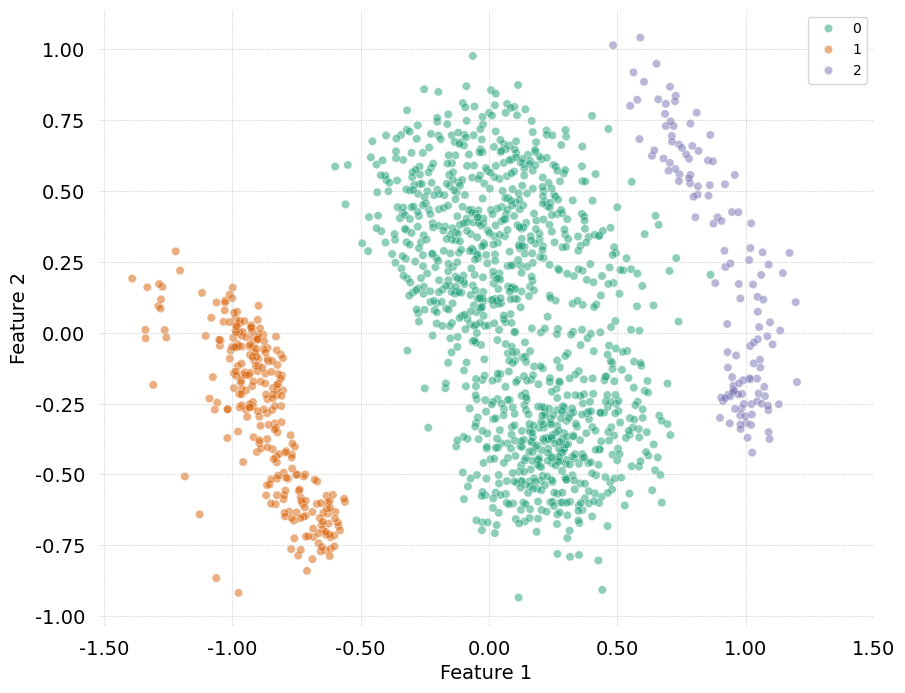

In [71]:
fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(
    x=D_transformed[:,0],
    y=D_transformed[:,1],
    alpha=0.5,
    hue=final_clusters.labels_,
    palette="Dark2",
    ax=ax)

#ax.set_title("NMDS visualization of the \nOSMI Mental Health in Tech Survey 2016")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xticks(np.arange(-1.5,1.75,0.5))
ax.set_xticklabels([f"{tick:.2f}" for tick in ax.get_xticks()], fontsize=14)
ax.set_yticks(np.arange(-1,1.25,0.25))
ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=14)
ax.tick_params(axis="both", length=0, pad=10)
ax.set_xlabel(r"Feature 1", fontsize=14)
ax.set_ylabel(r"Feature 2", fontsize=14)

## Describing the clusters

In [72]:
df_cluster = df.copy()

In [73]:
df_cluster["cluster"] = final_clusters.labels_

In [74]:
df_cluster["cluster"].value_counts(normalize=True)

cluster
0    0.718330
1    0.188960
2    0.092711
Name: proportion, dtype: float64

In [75]:
def cluster_profile(question, df):
    return (
        df.groupby("cluster")[question]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
        .pivot_table(values="proportion", index="cluster", columns=question)
    )

## Cluster characteristics

### General notes

- Clusters 0 and 2 consist of salaried employees, while cluster 1 is composed exclusively of self-employed workers.
- In both clusters 0 and 2, over 90% of respondents reported that they had not heard of or observed negative consequences for coworkers who disclosed mental health issues.
- Workers in clusters 0 and 1 reported similarly low awareness of mental health care options provided by their previous employers.
- Respondents in clusters 0 and 1 similarly reported that previous employers generally did not treat mental health with the same seriousness as physical health.
- Across all clusters, the majority of respondents stated that they would not disclse a mental health issue to a potential employer during a job interview.
- Family and friends represent the primary support system across clusters, with more than half of respondents reporting being somewhat to very open about sharing mental health issues with family or friends.
- Comparable proportions of workers in clusters 0 and 1 reported having been diagnosed with a mental health condition.
- No substantial differences in age distributions were observed across clusters; boxplots show considerable overlap.
- Gender distributions were comparable across all clusters.

### Cluster 0

- Predominantly employed in small to medium-sized companies.
- Report greater availability of employer-provided mental health benefits compared to cluster 2.
- Approximately 26% reported that their employer offers resources to learn about mental health, while 28% were unaware of such resources, suggesting limited visibility rather than absence.
- Slightly higher confidence in employer-provided anonymity when accessing mental health or substance abuse resources.
- Greater confidence in the ease of obtaining medical leave for mental health reasons; only 9.9% reported that it would be very difficult.
- Lower perceived risk of negative consequences from discussing mental health with employers compared to cluster 2.
- Approximately two-thirds reported being comfortable or potentially comfortable discussing mental health issues with coworkers.
- A similar proportion reported being comfortable or potentially comfortable discussing mental health issues with supervisors.
- All respondents in this cluster reported having had previous employers.
- A higher proportion reported that previous employers formally discussed mental health as part of campaigns or official communications.
- More positive experiences with previous employers providing mental health learning resources compared to clusters 1 and 2.
- Despite higher exposure to negative experiences in past workplaces, respondents in this cluster reported comparatively greater trust in employers.
- A higher proportion reported personal or family history of mental illness, higher diagnosis rates, and higher treatment-seeking behavior.
- Predominantly composed of technically specialized roles, such as back-end and front-end developers.

### Cluster 1

- The vast majority reported having previous employers.
- Fewer respondents reported that previous employers formally addressed mental health through campaigns or official communications.
- Reported limited access to employer-provided mental health learning resources in previous workplaces.
- Slightly higher trust in previous employers compared to cluster 0, despite fewer formal initiatives.
- A larger proportion reported having observed negative consequences for coworkers who disclosed mental health issues.
- Moderate concern that disclosure of mental health issues could negatively impact career prospects.
- Higher prevalence of unsupportive responses to mental health issues in past workplaces compared to other clusters.
- High prevalence of personal and family history of mental illness, diagnosis, and treatment-seeking.
- Predominantly composed of self-employed individuals fulfilling multiple roles (“one-person shops”).

### Cluster 2

- Predominantly employed in large organizations.
- Report fewer employer-provided mental health benefits compared to cluster 0.
- Lower reported availability of mental health learning resources, though awareness levels were similar or slightly higher than in cluster 0.
- Lower confidence in employer protection of anonymity when accessing mental health or substance abuse resources.
- Lower confidence in the ease of obtaining medical leave for mental health reasons.
- Higher perceived risk of negative consequences from discussing mental health issues with employers compared to cluster 0.
- More reserved attitudes toward discussing mental health issues with coworkers and supervisors.
- Composed exclusively of workers without previous employers.
- Higher concern that being identified as a person with a mental health issue could negatively affect career prospects.
- Despite reporting fewer negative experiences in the workplace, respondents in this cluster expressed the lowest levels of trust in employers.
- Lower prevalence of personal and family history of mental illness, diagnosis, and treatment-seeking compared to clusters 0 and 1.

In [76]:
for question in df_cluster.columns:
    if question == "cluster":
        continue
    elif question == "What is your age?":
        profile = df_cluster.groupby("cluster")[question].describe().reset_index()
    else:
        profile = cluster_profile(question, df_cluster)
    display(profile)   

Are you self-employed?,0,1
cluster,,
0,1.0,NaN
1,NaN,1.0
2,1.0,NaN


How many employees does your company or organization have?,1-5,100-500,26-100,500-1000,6-25,More than 1000,Not applicable
cluster,,,,,,,
0,0.050246,0.224631,0.257143,0.071921,0.181281,0.214778,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,0.068702,0.152672,0.236641,0.053435,0.198473,0.290076,NaN


Is your employer primarily a tech company/organization?,0.0,1.0,2.0
cluster,,,
0,0.223645,0.776355,NaN
1,NaN,NaN,1.0
2,0.274809,0.725191,NaN


Does your employer provide mental health benefits as part of healthcare coverage?,I don't know,No,Not applicable,Not eligible for coverage / N/A,Yes
cluster,,,,,
0,0.278818,0.182266,NaN,0.066010,0.472906
1,NaN,NaN,1.0,NaN,NaN
2,0.274809,0.213740,NaN,0.122137,0.389313


Do you know the options for mental health care available under your employer-provided coverage?,I am not sure,No,Yes,unknown
cluster,,,,
0,0.303448,0.306404,0.274877,0.115271
1,NaN,NaN,NaN,1.000000
2,0.335878,0.328244,0.213740,0.122137


...

"If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",Never,Not applicable to me,Often,Rarely,Sometimes
cluster,,,,,
0,0.008867,0.326108,0.372414,0.037438,0.255172
1,0.007491,0.284644,0.423221,0.029963,0.254682
2,0.007634,0.404580,0.335878,0.038168,0.213740


,cluster,count,mean,std,min,25%,50%,75%,max
0,0,1015.0,33.476847,6.776890,17.0,29.0,33.0,38.0,55.0
1,1,267.0,36.232210,7.872003,19.0,31.0,35.0,41.5,55.0
2,2,131.0,29.519084,7.807640,20.0,24.0,27.0,33.0,55.0


What is your gender?,female,male,non-binary
cluster,,,
0,0.237438,0.737931,0.024631
1,0.258427,0.722846,0.018727
2,0.198473,0.763359,0.038168


Which of the following best describes your work position?,Back-end Developer,Designer,Dev Evangelist/Advocate,DevOps/SysAdmin,Executive Leadership,Front-end Developer,HR,One-person shop,Other,Sales,Supervisor/Team Lead,Support
cluster,,,,,,,,,,,,
0,0.277833,0.022660,0.044335,0.105419,0.045320,0.168473,0.003941,0.004926,0.123153,0.002956,0.150739,0.050246
1,0.123596,0.059925,0.011236,0.074906,0.063670,0.134831,0.003745,0.359551,0.089888,0.003745,0.052434,0.022472
2,0.389313,0.045802,0.015267,0.053435,0.022901,0.206107,0.015267,0.015267,0.106870,0.007634,0.083969,0.038168


Do you work remotely?,Always,Never,Sometimes
cluster,,,
0,0.206897,0.258128,0.534975
1,0.453184,0.052434,0.494382
2,0.053435,0.427481,0.519084


In [77]:
results_independence_clusters = []
for question in df_cluster.columns:
    if question == "cluster" or question == "What is your age?":
        continue
    contingency_table = pd.crosstab(df_cluster["cluster"], df_cluster[question])
    chi2, pvalue, _, _ = chi2_contingency(contingency_table)
    v = association(contingency_table, method="cramer")

    result_independence = {
        "question" : question,
        "p_value" : pvalue,
        "chi2" : chi2,
        "cramers_v" : v
    }
    results_independence_clusters.append(result_independence)

results_independence = pd.DataFrame(results_independence_clusters)
results_independence = results_independence.sort_values(by="p_value", ascending=True)

reject, pvalue_corrected, _, _ = multipletests(
    results_independence["p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

results_independence["reject_h0"] = reject
results_independence["p_value_corrected"] = pvalue_corrected

In [78]:
results_independence

,question,p_value,chi2,cramers_v,reject_h0,p_value_corrected
0,Are you self-employed?,1.482342e-307,1413.000000,1.000000,True,6.374072e-306
12,Would you feel comfortable discussing a mental...,1.460567e-306,1433.342182,0.712179,True,3.140220e-305
2,Is your employer primarily a tech company/orga...,3.642885e-305,1415.117821,0.707636,True,5.221468e-304
14,Have you heard of or observed negative consequ...,1.004457e-304,1413.086439,0.707128,True,1.011769e-303
7,Is your anonymity protected if you choose to t...,1.176476e-304,1424.539840,0.709988,True,1.011769e-303
9,Do you think that discussing a mental health d...,1.928333e-303,1418.930645,0.708589,True,1.381972e-302
11,Would you feel comfortable discussing a mental...,2.725525e-303,1418.236680,0.708416,True,1.610654e-302
13,Do you feel that your employer takes mental he...,2.996565e-303,1418.046533,0.708368,True,1.610654e-302
6,Does your employer offer resources to learn mo...,5.856635e-303,1416.702529,0.708033,True,2.798170e-302
5,Has your employer ever formally discussed ment...,1.265813e-302,1415.156718,0.707646,True,5.442998e-302


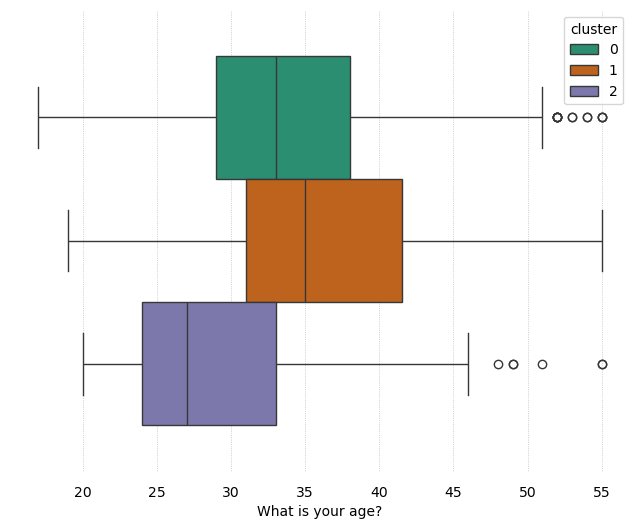

In [79]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(
    df_cluster,
    x="What is your age?",
    hue="cluster",
    palette="Dark2",
    ax=ax
)
ax.grid(True, linestyle=":", linewidth=0.5, axis="x")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)